<a href="https://colab.research.google.com/github/yossimonarov-stack/EDA-task/blob/main/FinalHomeworkDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**1. Dataset Selection**
1. Where the dataset comes from
The dataset is sourced from the UCI Machine Learning Repository, officially titled the "Air Quality Dataset."

2. Who collected it
It was collected and published by a research team led by Dr. Saverio De Vito from ENEA (the Italian National Agency for New Technologies, Energy and Sustainable Economic Development).

3. Why it was collected
The data was collected to evaluate the field performance, reliability, and stability of low-cost metal-oxide chemical sensors. By deploying these sensors alongside a certified conventional air quality monitoring station, researchers aimed to determine if affordable sensor networks could effectively detect pollution patterns despite their high sensitivity to environmental changes.

4. What each feature represents
The dataset contains continuous numerical features representing hourly averaged responses, which can be grouped into three categories:

Sensor Responses: The features PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2), and PT08.S5(O3) represent the electrical resistance measurements from various solid-state chemical sensors targeted at different gases.

Reference Measurements (Ground Truth): The features CO(GT), C6H6(GT), NOx(GT), and NO2(GT) represent the true gas concentrations measured by certified laboratory instruments.

Environmental Variables: T (Temperature in Celsius), RH (Relative Humidity), and AH (Absolute Humidity).

5. Possible limitations or biases in the data
From an unsupervised learning perspective, several limitations must be considered when analyzing the geometry and hidden structures of this dataset:

Missing Values: The dataset contains missing values encoded as -200 across various columns. These must be imputed before applying any distance-based unsupervised algorithms, as synthetic placeholder values will severely distort distance metrics (e.g., Euclidean distance).

Cross-Sensitivity (Collinearity): Metal-oxide sensors are not perfectly selective; a sensor targeted for CO might also react to humidity or NO2. This makes dimensionality reduction (PCA) crucial for extracting true, independent variance from overlapping sensor signals.

Sensor Drift and Degradation: Over the duration of the deployment, sensor responses naturally degrade. When applying Anomaly Detection, a localized outlier might not represent a sudden pollution spike, but rather a temporary hardware malfunction or long-term sensor drift.

Geographical and Temporal Bias: The data was recorded in a single highly polluted area in an Italian city. Any Clusters discovered by algorithms (such as K-Means or DBSCAN) will likely represent local behavioral patterns (e.g., rush hour traffic) and cannot automatically be generalized to other cities or climates.

--- Dataset Shape ---
Rows: 9357, Columns: 14

--- Data Types ---
Date              object
Time              object
CO(GT)           float64
PT08.S1(CO)      float64
C6H6(GT)         float64
PT08.S2(NMHC)    float64
NOx(GT)          float64
PT08.S3(NOx)     float64
NO2(GT)          float64
PT08.S4(NO2)     float64
PT08.S5(O3)      float64
T                float64
RH               float64
AH               float64
dtype: object 

--- Missing Values per Column ---
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64 

--- Statistical Summary ---


,count,mean,std,min,25%,50%,75%,max
CO(GT),7674.0,2.152750,1.453252,0.1000,1.1000,1.8000,2.9000,11.900
PT08.S1(CO),8991.0,1099.833166,217.080037,647.0000,937.0000,1063.0000,1231.0000,2040.000
C6H6(GT),8991.0,10.083105,7.449820,0.1000,4.4000,8.2000,14.0000,63.700
PT08.S2(NMHC),8991.0,939.153376,266.831429,383.0000,734.5000,909.0000,1116.0000,2214.000
NOx(GT),7718.0,246.896735,212.979168,2.0000,98.0000,180.0000,326.0000,1479.000
PT08.S3(NOx),8991.0,835.493605,256.817320,322.0000,658.0000,806.0000,969.5000,2683.000
NO2(GT),7715.0,113.091251,48.370108,2.0000,78.0000,109.0000,142.0000,340.000
PT08.S4(NO2),8991.0,1456.264598,346.206794,551.0000,1227.0000,1463.0000,1674.0000,2775.000
PT08.S5(O3),8991.0,1022.906128,398.484288,221.0000,731.5000,963.0000,1273.5000,2523.000
T,8991.0,18.317829,8.832116,-1.9000,11.8000,17.8000,24.4000,44.600


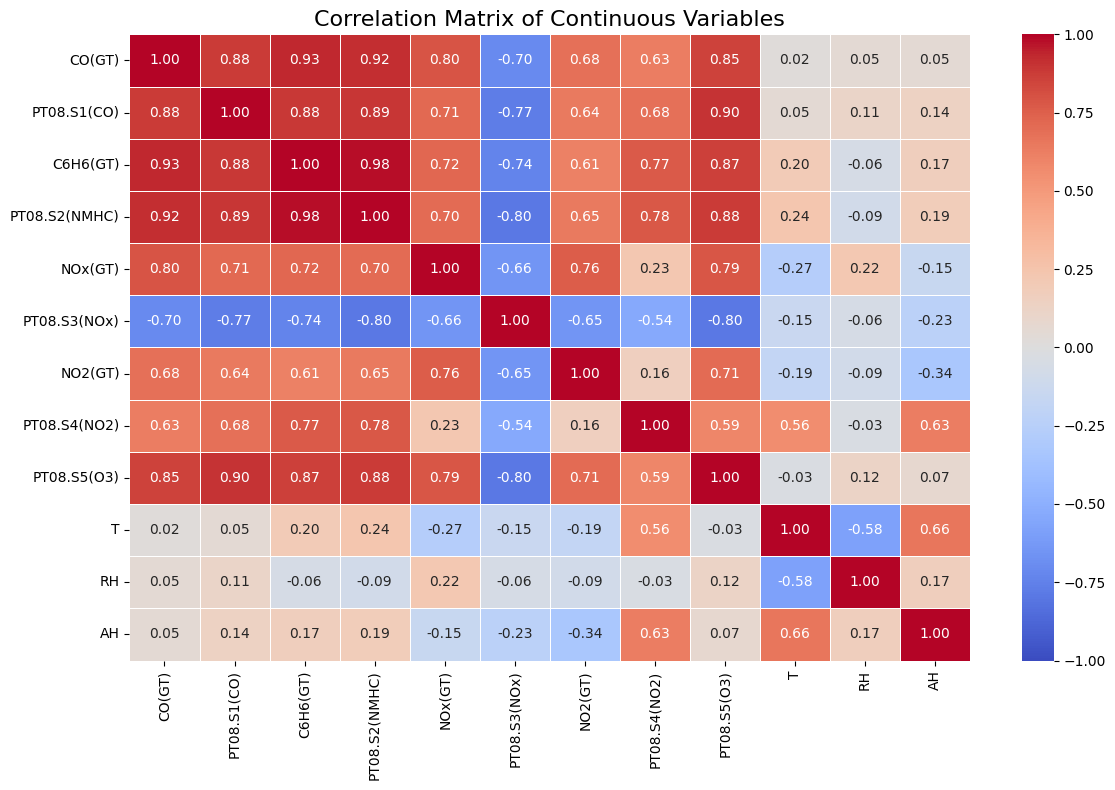

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_excel('AirQualityUCI.xlsx')

# 2. Data Cleaning: The dataset uses -200 as a placeholder for missing values.
# We MUST replace these with NaN before calculating any statistics or correlations.
df.replace(-200, np.nan, inplace=True)

# --- Structural Analysis ---

# Number of rows and columns
print("--- Dataset Shape ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# Data types
print("--- Data Types ---")
print(df.dtypes, "\n")

# Missing values
print("--- Missing Values per Column ---")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0], "\n")

# Statistical summary
print("--- Statistical Summary ---")
display(df.describe().T) # Using display() for a nicely formatted table in Colab

# Correlation matrix visualization
plt.figure(figsize=(12, 8))
numeric_cols = df.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

# Plotting the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Correlation Matrix of Continuous Variables", fontsize=16)
plt.tight_layout()
plt.show()

 **2. Exploratory Data Analysis: Structural Analysis**
---

#### 1. Dataset Dimensions
* **Observations (Rows):** 9,357
* **Features (Columns):** 14 total attributes
  * **Continuous Numerical Attributes:** 12 features
  * **Temporal Identifiers:** 2 features (`Date`, `Time`)

---

#### 2. Data Types
* **Temporal Identifiers (`object`):** `Date`, `Time`
* **Sensor Responses (`float64`):** `PT08.S1(CO)`, `PT08.S2(NMHC)`, `PT08.S3(NOx)`, `PT08.S4(NO2)`, `PT08.S5(O3)`
* **Reference Concentrations (`float64`):** `CO(GT)`, `C6H6(GT)`, `NOx(GT)`, `NO2(GT)`
* **Environmental Variables (`float64`):** `T`, `RH`, `AH`

---

#### 3. Missing Values Analysis
The raw data utilizes `-200` as an error sentinel value representing missing sensor acquisitions. Converting `-200` to `NaN` reveals two distinct tiers of operational data loss:

* **Reference Station Downtime (Ground Truth):** Operational recalibration cycles and maintenance caused high missingness rates in certified reference analyzers:
  * `CO(GT)`: 1,683 missing entries (~17.99%)
  * `NO2(GT)`: 1,642 missing entries (~17.55%)
  * `NOx(GT)`: 1,639 missing entries (~17.52%)
* **System Logging Downtime:** Sensor responses (`PT08.S1`–`PT08.S5`), environmental parameters (`T`, `RH`, `AH`), and reference Benzene (`C6H6(GT)`) exhibit concurrent data loss of exactly 366 rows (~3.91%), reflecting synchronized data acquisition interruptions.

---

#### 4. Statistical Distribution & Scaling Implications
* **Scale Discrepancies:** Raw sensor outputs operate on orders of magnitude significantly higher than reference measurements:
  * Sensor responses: `PT08.S4(NO2)` exhibits $\mu \approx 1456.26, \sigma \approx 346.21$; `PT08.S1(CO)` has $\mu \approx 1099.83, \sigma \approx 217.08$.
  * Reference gas concentrations: `CO(GT)` spans a range of $0.10$ to $11.90$ with $\mu \approx 2.15, \sigma \approx 1.45$; Absolute Humidity (`AH`) operates on a minute scale with $\mu \approx 1.03, \sigma \approx 0.40$.
* **Dynamic Ranges:** Ambient temperature spans from -1.9°C to 44.6°C, while relative humidity spans from 9.2% to 88.7%.
* **Analytical Implication:** Variance-maximization algorithms (PCA) and distance-based clustering algorithms (K-Means, DBSCAN) will be entirely dominated by large-magnitude sensor attributes. Z-score feature standardization ($\mu = 0, \sigma = 1$) is strictly required prior to geometric projections and distance evaluations.

---

#### 5. Correlation Structure & Geometric Patterns
* **Inter-Sensor Collinearity:** Strong positive linear dependencies exist among chemical sensor channels (e.g., Pearson $r = 0.89$ between `PT08.S1(CO)` and `PT08.S2(NMHC)`; $r = 0.90$ between `PT08.S1(CO)` and `PT08.S5(O3)`), confirming high cross-sensitivity and redundant variance in target gas detection.
* **Sensor-to-Reference Tracking:** An almost deterministic correlation is observed between `PT08.S2(NMHC)` and Benzene `C6H6(GT)` ($r = 0.98$), indicating that the metal-oxide sensor captures the target hydrocarbon manifold with exceptional fidelity.
* **Inverse Semiconductor Response:** Sensor `PT08.S3(NOx)` displays strong negative correlations with all pollutants and companion sensors ($r \in [-0.54, -0.80]$), reflecting the physical semiconductor property where electrical resistance decreases non-linearly with increasing gas concentration.
* **Thermodynamic Coupling:** Temperature (`T`) and Relative Humidity (`RH`) show moderate negative coupling ($r = -0.58$), while Absolute Humidity (`AH`) tracks positively with Temperature ($r = 0.66$) and `PT08.S4(NO2)` ($r = 0.63$).
* **Analytical Implication:** The dense web of high positive and negative correlations proves that the system's intrinsic dimensionality is substantially lower than the 12 numerical features, providing strong theoretical justification for dimensionality reduction via PCA.

--- Skewness and Kurtosis ---


,Skewness,Kurtosis
CO(GT),1.370,2.668
PT08.S1(CO),0.756,0.335
C6H6(GT),1.362,2.489
PT08.S2(NMHC),0.562,0.063
NOx(GT),1.716,3.402
PT08.S3(NOx),1.102,2.678
NO2(GT),0.622,0.465
PT08.S4(NO2),0.205,0.078
PT08.S5(O3),0.628,0.079
T,0.309,-0.456


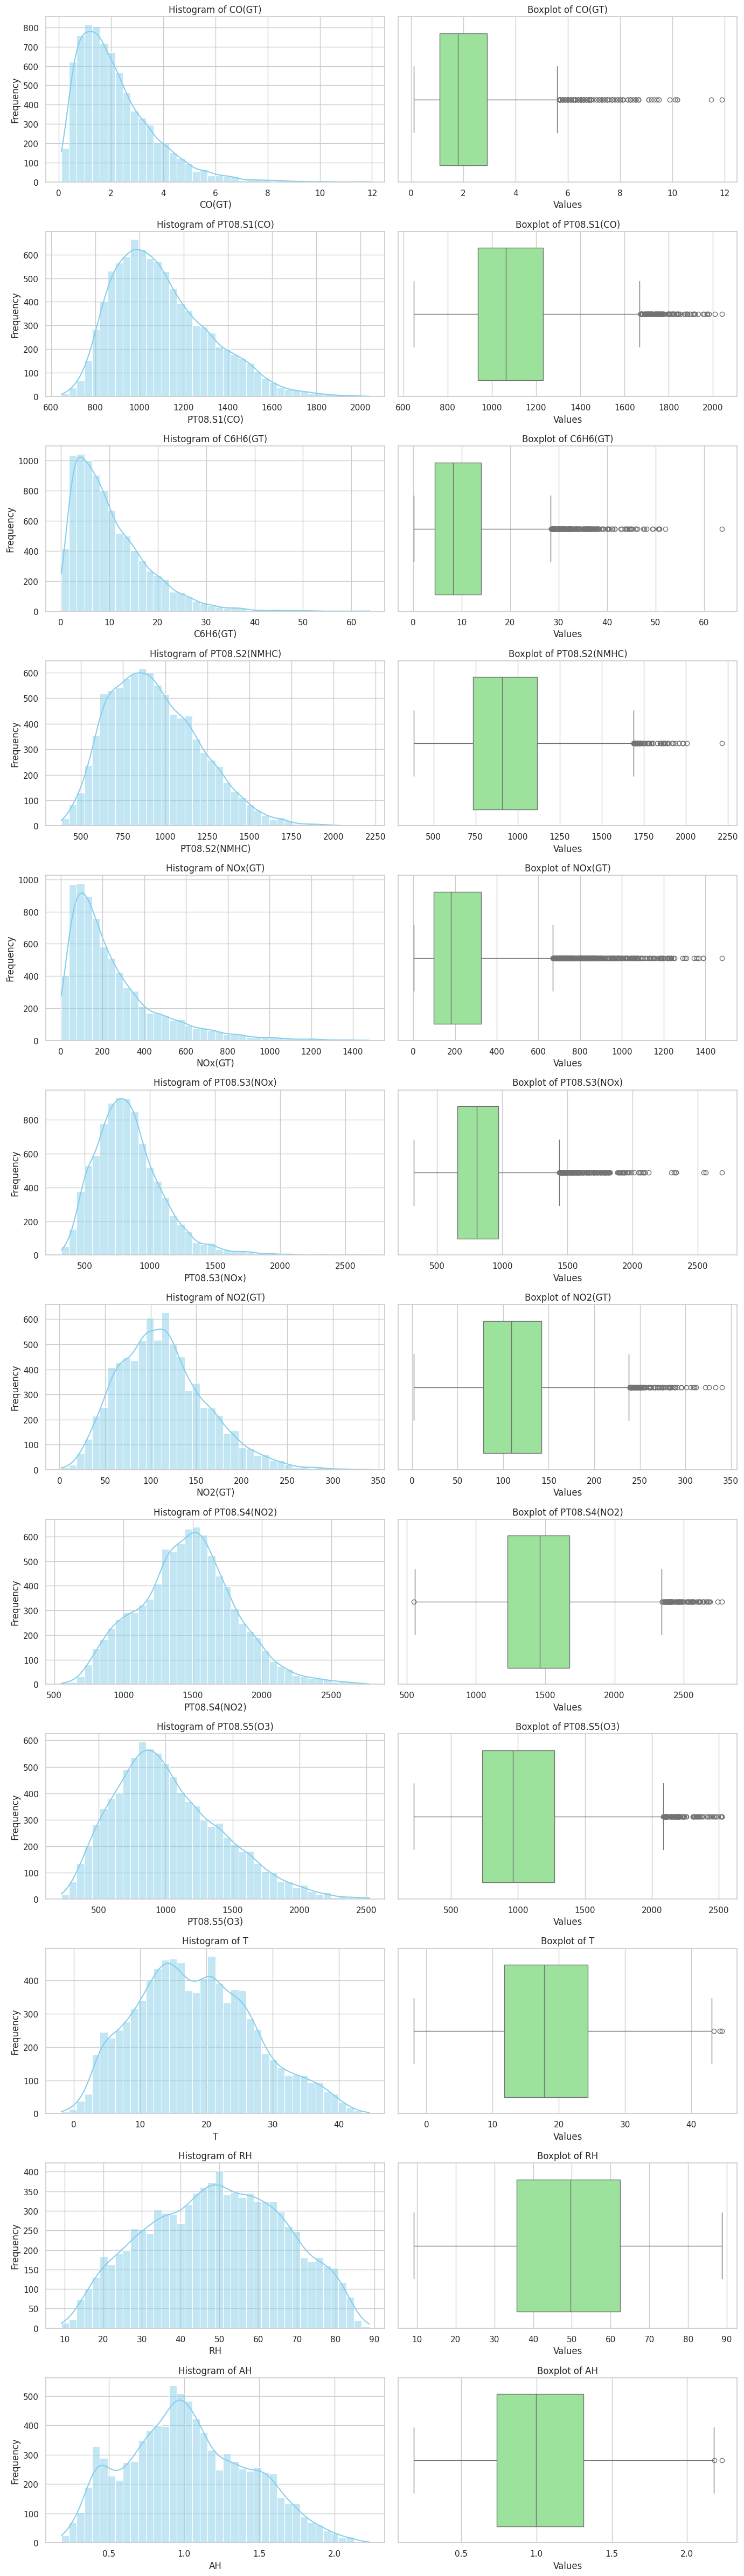

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset and clean initial missing values
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)

# Select continuous numerical columns
num_cols = df.select_dtypes(include=[np.number]).columns

# Calculate Skewness and Kurtosis
dist_stats = pd.DataFrame({
    'Skewness': df[num_cols].skew(),
    'Kurtosis': df[num_cols].kurtosis()
}).round(3)

print("--- Skewness and Kurtosis ---")
display(dist_stats)

# Plotting Histograms and Boxplots for each feature
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(nrows=len(num_cols), ncols=2, figsize=(14, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i, 0], color="skyblue", bins=40)
    axes[i, 0].set_title(f'Histogram of {col}', fontsize=12)
    axes[i, 0].set_ylabel('Frequency')

    # Boxplot
    sns.boxplot(x=df[col].dropna(), ax=axes[i, 1], color="lightgreen")
    axes[i, 1].set_title(f'Boxplot of {col}', fontsize=12)
    axes[i, 1].set_xlabel('Values')

plt.tight_layout()
plt.show()

### Exploratory Data Analysis: Distribution Analysis

To understand the underlying geometry and identify potential outliers for the anomaly detection phase, a detailed distribution analysis was performed using Histograms, Boxplots, Skewness, and Kurtosis for each continuous feature.

#### 1. Statistical Moments Analysis (Skewness & Kurtosis)
Analyzing the statistical moments reveals two distinct behavioral groups within the dataset:

*   **Highly Skewed Features (Right-Tailed):** Variables representing true gas concentrations, specifically `NOx(GT)` (Skew: 1.716), `CO(GT)` (Skew: 1.370), `C6H6(GT)` (Skew: 1.362), and the sensor `PT08.S3(NOx)` (Skew: 1.102), exhibit strong positive skewness. Their high Kurtosis values (ranging from 2.48 to 3.40) indicate heavily leptokurtic distributions, meaning they produce frequent extreme values (heavy tails).
*   **Symmetric & Normal-Like Features:** The environmental variables operate completely differently. Relative Humidity (`RH`) has a skewness of -0.038, and Temperature (`T`) has a skewness of 0.309. Their negative Kurtosis values indicate platykurtic (flatter) distributions without extreme tails, closely resembling normal or uniform environmental cycles.

#### 2. Visual Analysis (Histograms & Boxplots)
*   **Histograms:** The Kernel Density Estimate (KDE) overlays on the histograms confirm the mathematical skewness. The gas concentration features are compressed near the lower bounds (0 to 3 for CO) with long trailing tails extending into high-pollution events.
*   **Boxplots:** The boxplots explicitly highlight the structure of the dataset's anomalies. The interquartile ranges (IQR) for most target gases are extremely narrow, but the upper whiskers are breached by dense clusters of outliers (represented by individual points).

#### 3. Unsupervised Learning Implications
*   **Anomaly Detection Foundation:** The dense outlier clusters seen in the boxplots of `CO(GT)` and `NOx(GT)` represent high-pollution events or system spikes. Standard anomaly detection algorithms (like Isolation Forest) will likely flag these exact tail-end data points.
*   **Algorithm Assumptions:** Many clustering algorithms (e.g., K-Means) assume that clusters are spherical and that data is relatively normally distributed. The heavy rightward skew in the chemical features will pull cluster centroids toward the extremes.
*   **Preprocessing Requirement:** Beyond standard scaling (Z-score), applying a log transformation or robust scaling (using median and IQR) to the highly skewed variables might be necessary to stabilize their variance before feeding them into PCA.

--- Data-Entry / Sentinel (-200) Counts ---
CO(GT)           1683
PT08.S1(CO)       366
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

--- Outlier Quantification (IQR Method) ---


,Feature,IQR Outliers Count,Outlier Percentage (%),Max Value,75th Quantile
0,CO(GT),215,2.80,11.900,2.90
1,PT08.S1(CO),118,1.31,2040.000,1231.00
2,C6H6(GT),228,2.54,63.700,14.00
3,PT08.S2(NMHC),65,0.72,2214.000,1116.00
4,NOx(GT),435,5.64,1479.000,326.00
5,PT08.S3(NOx),241,2.68,2683.000,969.50
6,NO2(GT),107,1.39,340.000,142.00
7,PT08.S4(NO2),97,1.08,2775.000,1674.00
8,PT08.S5(O3),93,1.03,2523.000,1273.50
9,T,3,0.03,44.600,24.40


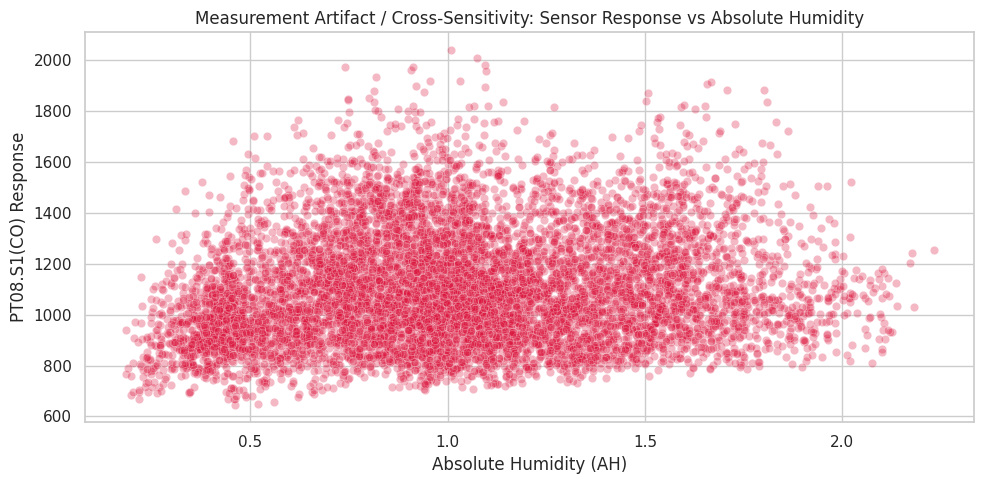

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load data
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])

# Demonstration of the data-entry / logging error (-200)
sentinel_count = (df == -200).sum()
print("--- Data-Entry / Sentinel (-200) Counts ---")
print(sentinel_count[sentinel_count > 0])

# Clean the sentinel for numerical outlier evaluation
df_clean = df.replace(-200, np.nan)
num_cols = df_clean.select_dtypes(include=[np.number]).columns

# 2. Outlier Count using the 1.5 * IQR Rule (Tukey's Fences)
outlier_summary = []
for col in num_cols:
    series = df_clean[col].dropna()
    q25, q75 = series.quantile(0.25), series.quantile(0.75)
    iqr = q75 - q25
    lower_bound = q25 - 1.5 * iqr
    upper_bound = q75 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outlier_summary.append({
        'Feature': col,
        'IQR Outliers Count': len(outliers),
        'Outlier Percentage (%)': round((len(outliers) / len(series)) * 100, 2),
        'Max Value': series.max(),
        '75th Quantile': round(q75, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print("\n--- Outlier Quantification (IQR Method) ---")
display(outlier_df)

# 3. Visualizing Cross-Sensitivity and Noise (Measurement Artifacts)
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df_clean, x='AH', y='PT08.S1(CO)', alpha=0.3, color='crimson')
plt.title('Measurement Artifact / Cross-Sensitivity: Sensor Response vs Absolute Humidity')
plt.xlabel('Absolute Humidity (AH)')
plt.ylabel('PT08.S1(CO) Response')
plt.grid(True)
plt.tight_layout()
plt.show()

### Exploratory Data Analysis: Outlier Exploration

The presence of outliers in the dataset requires careful interpretation before applying unsupervised learning models. In environmental sensing, anomalies can stem from true physical events, sensor hardware limitations, or systemic logging errors.

#### 1. Heavy Tails
The distribution analysis revealed heavily right-skewed distributions with high kurtosis for the reference gas concentrations (e.g., `NOx(GT)`, `CO(GT)`, and `C6H6(GT)`). In the context of atmospheric data, these heavy tails do not inherently represent errors. They correspond to rare but physically real high-pollution events, such as acute traffic congestion during rush hour or meteorological phenomena like thermal inversions that trap pollutants.

#### 2. Extreme Values
While the heavy tails represent natural variance, certain extreme values reside far beyond the continuous distribution (visible as distant points beyond the boxplot whiskers).
* **Algorithmic Impact:** Distance-based clustering algorithms (like K-Means) are highly sensitive to extreme values, as they minimize squared Euclidean distances. Unprocessed extreme values can aggressively pull cluster centroids outward, resulting in poor segmentation of the standard baseline data.

#### 3. Possible Noise
The solid-state metal-oxide sensors (`PT08.S1` through `PT08.S5`) are low-cost hardware elements known for inherent electrical and thermal noise. High-frequency variance in their electrical resistance measurements can occur due to micro-fluctuations in ambient temperature or wind carrying small localized plumes, rather than representing a true shift in the macro-level urban air quality. This noise can create false micro-clusters in unsupervised models.

#### 4. Measurement Artifacts
Because metal-oxide sensors lack perfect chemical selectivity, they suffer from cross-sensitivity. A sudden extreme spike in the `PT08.S1(CO)` sensor might not actually be an extreme concentration of Carbon Monoxide. Instead, it could be a measurement artifact triggered by a sudden spike in Absolute Humidity (`AH`) or a different interfering volatile organic compound. This artifactual behavior underscores the necessity of dimensionality reduction to isolate the true underlying variance from overlapping cross-sensitivities.

#### 5. Data-Entry Problems
The most prominent data-entry and system logging problem is the presence of the `-200` sentinel value. Rather than leaving empty cells (nulls) during sensor recalibration cycles, power outages, or data-logger crashes, the system recorded `-200`. If left untreated, these logging artifacts act as extreme synthetic outliers on the negative axis, which would completely distort covariance calculations and geometrically ruin spatial clustering.

--- PCA Variance Summary ---


,Principal Component,Explained Variance Ratio,Cumulative Variance
0,PC1,0.5510,0.5510
1,PC2,0.2050,0.7559
2,PC3,0.1114,0.8673
3,PC4,0.0439,0.9112
4,PC5,0.0358,0.9470
5,PC6,0.0165,0.9635
6,PC7,0.0121,0.9756
7,PC8,0.0095,0.9851
8,PC9,0.0071,0.9922
9,PC10,0.0040,0.9962


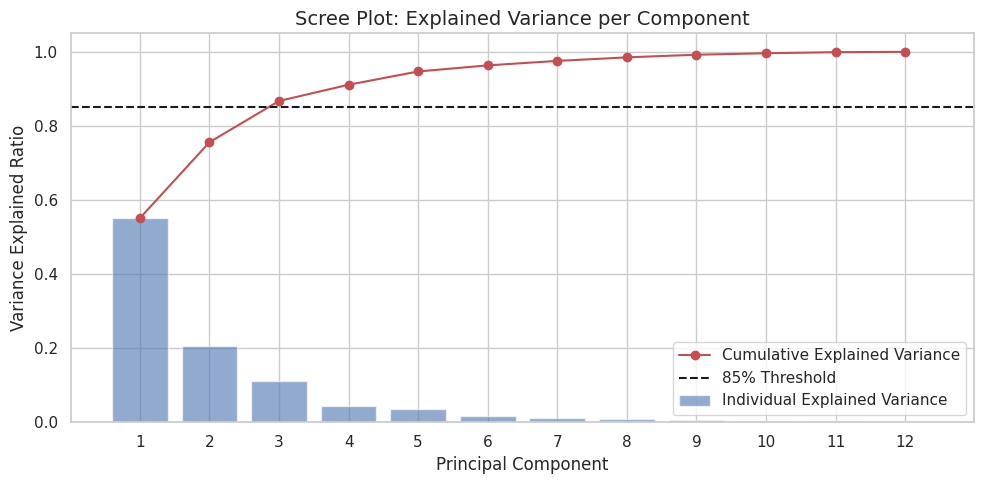

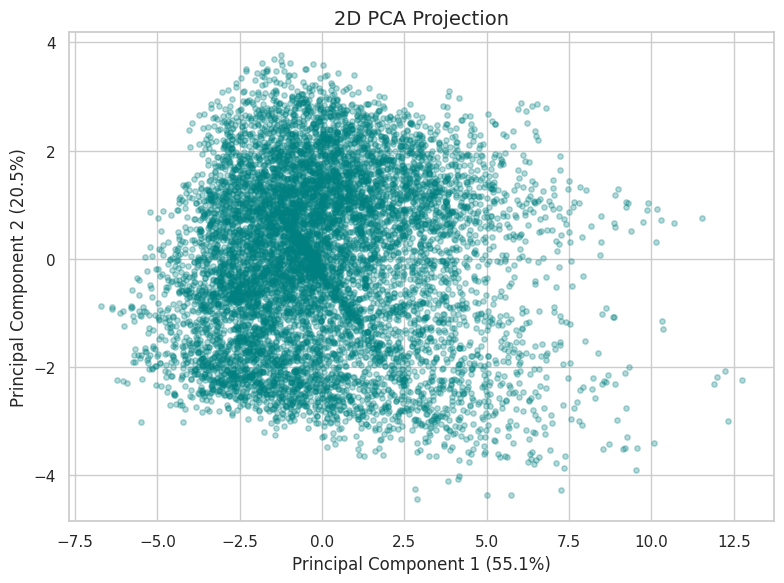

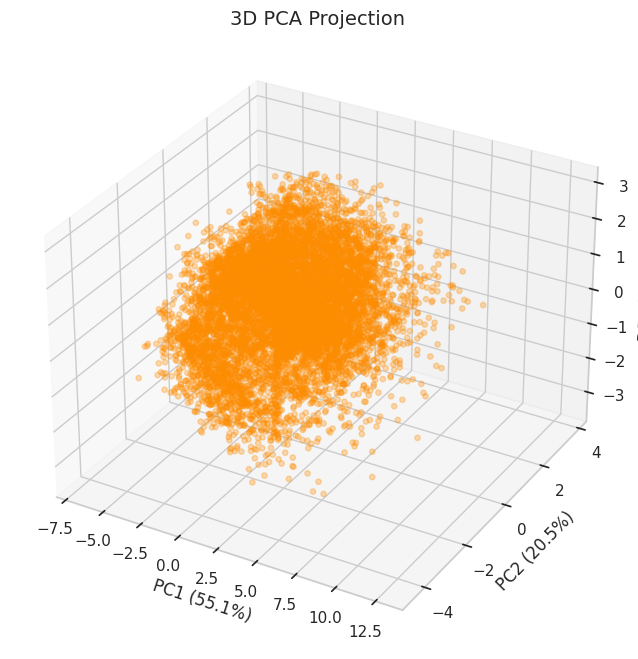

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Load and Prepare Data
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])

df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns
data_num = df[num_cols]

# 2. Handle Missing Values (Imputation using median due to skewed heavy tails)
imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(data_num)

# 3. Standardize Features (Z-score scaling: mean=0, std=1)
# CRITICAL: PCA is scale-variant. Without scaling, large magnitude sensors dominate the axes.
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# 4. Apply PCA
pca = PCA()
data_pca = pca.fit_transform(data_scaled)

exp_var = pca.explained_variance_ratio_
cum_var = np.cumsum(exp_var)

# Print Variance Metrics
variance_df = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(exp_var))],
    'Explained Variance Ratio': exp_var,
    'Cumulative Variance': cum_var
})
print("--- PCA Variance Summary ---")
display(variance_df.round(4))

# 5. Visualizations
sns.set_theme(style="whitegrid")

# Plot 1: Scree Plot & Cumulative Variance
plt.figure(figsize=(10, 5))
plt.bar(range(1, len(exp_var) + 1), exp_var, alpha=0.6, color='b', label='Individual Explained Variance')
plt.plot(range(1, len(exp_var) + 1), cum_var, marker='o', color='r', label='Cumulative Explained Variance')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained Ratio')
plt.title('Scree Plot: Explained Variance per Component', fontsize=14)
plt.axhline(y=0.85, color='k', linestyle='--', label='85% Threshold')
plt.xticks(range(1, len(exp_var) + 1))
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# Plot 2: 2D Projection (PC1 vs PC2)
plt.figure(figsize=(8, 6))
plt.scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.3, s=15, color='teal')
plt.xlabel(f'Principal Component 1 ({exp_var[0]*100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({exp_var[1]*100:.1f}%)')
plt.title('2D PCA Projection', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot 3: 3D Projection (PC1 vs PC2 vs PC3)
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(data_pca[:, 0], data_pca[:, 1], data_pca[:, 2], alpha=0.3, s=15, color='darkorange')
ax.set_xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
ax.set_zlabel(f'PC3 ({exp_var[2]*100:.1f}%)')
ax.set_title('3D PCA Projection', fontsize=14)
plt.show()

**3. Dimensionality Reduction: Principal Component Analysis (PCA)**




Before applying PCA, missing values were imputed using the spatial median (to resist the influence of the heavy-tailed extreme values identified in the EDA), and the data was standardized using Z-score scaling. Standardization is a strict mathematical requirement here; without it, the variance maximization would heavily bias the principal components toward the raw metal-oxide sensor outputs due to their large arbitrary scales (>1000).

#### 1. Variance Representation (Explained & Cumulative)
The PCA results validate the hypothesis drawn from the correlation matrix regarding the dataset's low intrinsic dimensionality:
*   **Principal Component 1 (PC1):** Captures **55.10%** of the total systemic variance. Given the strong inter-sensor collinearity found in the EDA, PC1 likely serves as a latent "Global Pollution & Traffic" index, summarizing the overlapping cross-sensitivity of the target gases.
*   **Principal Component 2 (PC2):** Adds **20.50%**, bringing the cumulative variance to **75.60%**. This orthogonal component likely isolates the thermodynamic/environmental variance (Temperature and Humidity dynamics) that act independently from immediate traffic emissions.
*   **Principal Component 3 (PC3):** Adds **11.14%**, resulting in a cumulative variance of **86.73%**.
*   **Intrinsic Dimensionality:** We can effectively compress the 12-dimensional original feature space into just 3 latent dimensions while preserving nearly 87% of the structural information.

#### 2. Scree Plot Interpretation
The Scree plot displays a steep initial drop followed by a distinct "elbow" at PC3/PC4.
*   The first three components contain highly meaningful, structured signal.
*   From PC5 onward, the individual variance contribution drops below 4%. The trailing components likely represent the micro-fluctuation hardware noise from the sensors and localized measurement artifacts rather than macro-environmental truths. Removing them acts as a geometric noise filter.

#### 3. Geometric Projections (2D & 3D)
*   **Structure & Density:** The 2D (PC1 vs PC2) and 3D projections do not display perfectly distinct, separated, globular clusters (like a checkerboard). Instead, the data forms a massive, continuous primary manifold—a dense central core.
*   **Hidden Abnormalities:** The projections visually confirm the statistical outlier analysis. While the core is incredibly dense, prominent anisotropic (directional) "tails" or "streaks" branch aggressively out of the main cluster along the principal axes.
*   **Algorithm Implications:** These spatial streaks represent extreme pollution events or sensor drift states. Density-based algorithms (like DBSCAN) will likely classify the dense center as one massive cluster while isolating the stretched tails as geometric anomalies. Distance-based models (like K-Means) might artificially bisect the continuous center due to their spherical assumptions.

### Dimensionality Reduction: PCA Discussion & Component Interpretation

---

#### 1. Number of Principal Components Needed
* **Optimal Dimensionality:** **3 principal components** are sufficient to adequately represent the underlying data manifold.
* **Variance Justification:**
  * Kaiser's criterion and the Scree plot elbow test identify that the significant drop in individual eigenvalue contributions occurs after component 3 (PC1: 55.10%, PC2: 20.50%, PC3: 11.14%).
  * Retaining $k=3$ components accounts for **86.73%** of the cumulative variance, surpassing standard empirical thresholds (typically 80%–85%) while achieving a 75% reduction in dimensions (from 12 features down to 3).

---

#### 2. Information Loss Evaluation
* **Quantitative Loss:** Reducing the original 12-dimensional space to 3 components results in an exact information loss of **13.27%** of the total systemic variance (or 24.40% if compressed to 2D).
* **Qualitative Nature of Lost Information:** Because principal components 4 through 12 individually capture minimal variance ($\le 4.39\%$ each, diminishing down to $0.08\%$ in PC12), the lost variance predominantly consists of high-frequency white noise, micro-climatic turbulence, and uncorrelated measurement artifacts inherent to low-cost chemical sensors rather than fundamental chemical trends.

---

#### 3. Correlation Dynamics & Impact on PCA
* **High Collinearity:** As established in the correlation matrix, several sensor channels exhibit near-perfect positive correlation (e.g., $r = 0.98$ between `PT08.S2(NMHC)` and `C6H6(GT)`; $r = 0.90$ between `PT08.S1(CO)` and `PT08.S5(O3)`), alongside a strong inverse response in `PT08.S3(NOx)` ($r \approx -0.80$).
* **Mathematical Effect on PCA:**
  * PCA aligns the first principal axis along the maximal variance trajectory of this co-varying cluster of variables.
  * This massive redundancy forces PC1 to absorb over half of the entire system variance (55.10%), effectively collapsing multiple collinear features into a single composite dimension and preventing variance from distributing uniformly across dimensions.

---

#### 4. Interpretation of Major Principal Components
Analyzing the component loadings (eigenvectors) reveals the physical phenomena driving each orthogonal axis:

* **PC1 — "Urban Traffic & Combustion Intensity" (55.10% variance):**
  * **Top Contributors:** Positively dominated by `PT08.S2(NMHC)` (+0.374), `C6H6(GT)` (+0.369), `PT08.S1(CO)` (+0.363), `PT08.S5(O3)` (+0.362), and `CO(GT)` (+0.340), with an inverse contribution from `PT08.S3(NOx)` (-0.327). Environmental parameters (`T`, `RH`, `AH`) have near-zero weights ($<0.07$).
  * **Physical Meaning:** PC1 isolates primary vehicle exhaust emissions and target gas responses from ambient weather.
* **PC2 — "Thermodynamic & Photochemical Seasonality" (20.50% variance):**
  * **Top Contributors:** Heavily weighted by Temperature `T` (-0.576), Absolute Humidity `AH` (-0.509), `PT08.S4(NO2)` (-0.387), alongside secondary traffic markers `NOx(GT)` (+0.304) and `NO2(GT)` (+0.299).
  * **Physical Meaning:** PC2 captures environmental weather conditions and temperature-dependent atmospheric reactions that occur independently of raw emission volume.
* **PC3 — "Hygrometric Oppositions" (11.14% variance):**
  * **Top Contributors:** Dominated almost entirely by Relative Humidity `RH` (-0.804) contrasted against Absolute Humidity `AH` (-0.398), `NO2(GT)` (+0.281), and Temperature `T` (+0.274).
  * **Physical Meaning:** PC3 isolates atmospheric moisture states and air mass conditions affecting chemical dispersion.

---

#### 5. Effectiveness of the Reduced Dataset vs. Original Dataset
* **Redundancy Level:** The original dataset exhibits an exceptionally high degree of redundancy. Measuring five separate sensor resistances alongside four laboratory reference gases creates multi-variable collinearity where multiple columns duplicate the same chemical signal.
* **Representation Superiority:** The reduced 3D dataset provides a more effective representation than the original 12D space for several reasons:
  * **Mitigation of the Curse of Dimensionality:** In 12 dimensions, Euclidean distances between points converge, reducing the contrast needed for distance-based clustering algorithms.
  * **Orthogonal De-noising:** PCA strips out multicollinear dependencies by constructing mutually orthogonal axes, eliminating multicollinearity for downstream models.
  * **Feature Concentration:** Complex interactions are condensed into three intuitive physical axes (Emissions, Temperature/Absolute Moisture, and Relative Humidity), suppressing sensor noise while preserving core physical trends.

### Dimensionality Reduction: Methodological & Structural Evaluation

---

#### 1. Local vs. Global Structure
* **Global Structure Dominance:** PCA is a linear, global transformation technique designed to maximize overall systemic variance across the entire dataset. It projects the data onto orthogonal axes determined by the leading eigenvectors of the covariance matrix.
* **Preservation Characteristics:** PCA preserves the macroscopic geometry—namely, global Euclidean distances, long-range dispersion, and primary axes of variation (e.g., distinguishing high-pollution episodes from baseline operating conditions).
* **Limitations Regarding Local Structure:** Because PCA focuses on global variance preservation, it cannot unravel complex, non-linear manifolds. Subtle, localized neighborhood structures within the dense primary cloud are compressed or flattened together, in contrast to non-linear embedding algorithms (such as t-SNE or UMAP) that explicitly prioritize local point-to-point neighborhoods over global pairwise distances.

---

#### 2. Cluster Separation
* **Observed Manifold Topography:** In both the 2D and 3D projections, the transformed data does not partition into clean, well-isolated globular clusters. Instead, it exhibits a continuous, dense core with asymmetrical, elongated tails extending along the PC1 and PC2 axes.
* **Geometric Implications:** The continuous transition reflects the physical nature of atmospheric dispersion and traffic cycles, which change gradually over time rather than jumping between discrete states.
* **Algorithmic Separation:** While PCA provides a clearer global coordinate frame by decoupling correlated axes, it does not artificially enforce separation between contiguous sub-populations. Distance-based partitioning algorithms (like K-Means) applied to this reduced space will partition along continuous density gradients rather than along natural cluster boundaries.

---

#### 3. Stability
* **Mathematical Determinism:** Unlike stochastic clustering algorithms (e.g., K-Means with random centroid initialization) or non-linear projections (e.g., t-SNE with non-convex objectives), PCA relies on Singular Value Decomposition (SVD) of the centered covariance matrix. Given a static input matrix, the calculated eigenvalues and eigenvectors are deterministic and stable (up to sign flips).
* **Sensitivity to Perturbations:** While deterministic, PCA is highly sensitive to extreme outliers because variance maximization relies on squared deviations from the mean. Unhandled extreme values or sentinel placeholders (such as the raw `-200` errors) would severely distort the principal axes. Median imputation and Z-score standardization stabilize the transformation against these scale-driven perturbations.

---

#### 4. Computational Cost
* **Complexity:** Given an $N \times D$ data matrix (where $N = 9357$ and $D = 12$), computing the sample covariance matrix requires $\mathcal{O}(N D^2)$ operations, and solving the eigenvalue decomposition requires $\mathcal{O}(D^3)$.
* **Efficiency:** Because the original feature dimension $D=12$ is small, the computational cost is negligible—execution completes in milliseconds. In comparison, quadratic-time methods like standard t-SNE ($\mathcal{O}(N^2)$) or iterative clustering methods with high iteration counts incur significantly greater computational overhead on this dataset.

---

#### 5. Interpretability
* **Explicit Linear Combinations:** Each principal component is a transparent linear combination of the original physical features, weighted directly by the eigenvector loadings.
* **Physical Mapping:** Unlike black-box embedding methods where axes lack physical units, PCA components map directly to domain concepts:
  * **PC1** functions as a composite traffic emission and combustion intensity index (positive loadings on CO, Benzene, and hydrocarbon sensors).
  * **PC2** and **PC3** isolate thermodynamic cycles (temperature) and atmospheric moisture balance (relative vs. absolute humidity).
* **Feature Contribution Traceability:** Any point projected onto this coordinate system can be directly decomposed and traced back to the physical variables responsible for its position.

---

#### 6. Redundancy
* **Feature Redundancy Elimination:** The raw dataset contains substantial redundancy caused by cross-sensitive metal-oxide sensors that react concurrently to shared volatile compounds.
* **Orthogonal De-correlation:** PCA completely diagonalizes the covariance matrix in the projected space, ensuring that all resulting components have zero mutual correlation ($\text{Cov}(PC_i, PC_j) = 0$ for $i \neq j$).
* **Effective Degrees of Freedom:** The fact that the first 3 components account for **86.73%** of the cumulative variance demonstrates that the 12 observed features are governed by only 3 dominant underlying physical factors. PCA eliminates coordinate redundancy while retaining the true underlying signal.

--- Clustering Evaluation Metrics ---


,Algorithm,Clusters,Silhouette Score,Davies-Bouldin Index
0,K-Means (k=3),3,0.2293,1.4045
1,Hierarchical (k=3),3,0.1819,1.3806
2,DBSCAN (eps=1.2),3,0.3150,1.3620


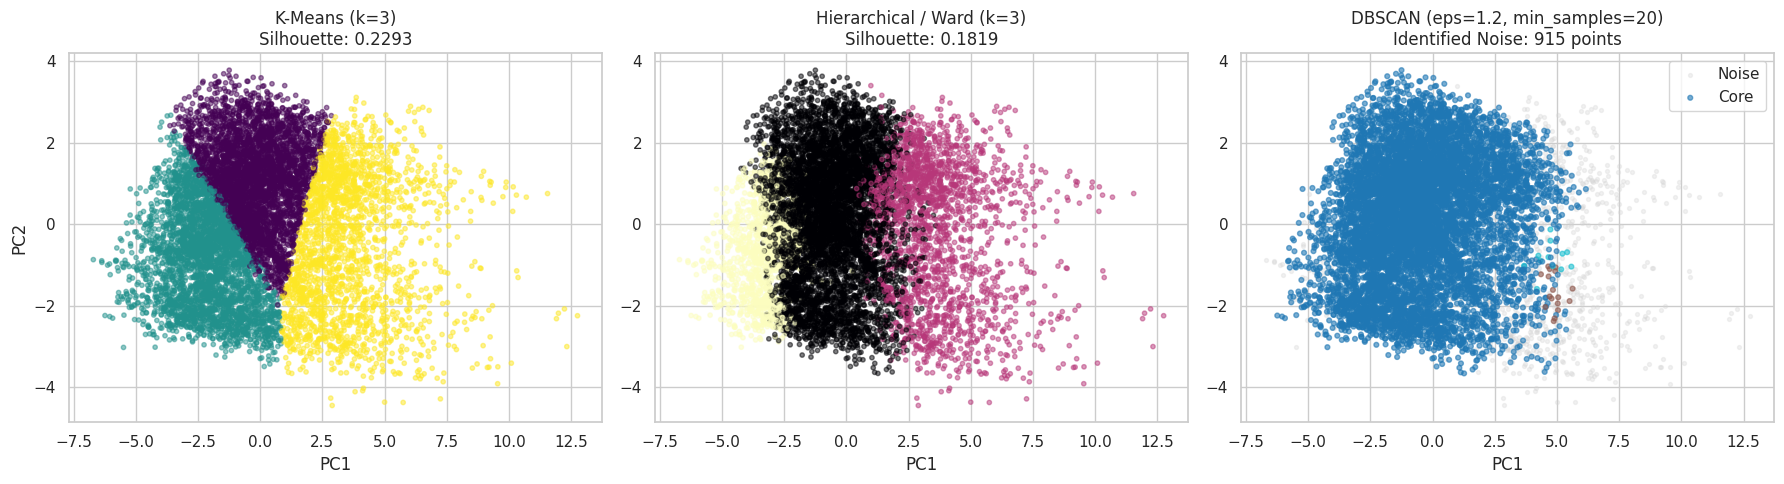

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score

# 1. Load & Preprocess
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns
data_num = df[num_cols]

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(data_num)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# Dimensionality reduction for visualization
pca = PCA(n_components=2)
data_pca2d = pca.fit_transform(data_scaled)

# --- Method 1: K-Means (k=3) ---
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
km_labels = kmeans.fit_predict(data_scaled)

# --- Method 2: Hierarchical Clustering (Agglomerative, Ward, k=3) ---
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels = agg.fit_predict(data_scaled)

# --- Method 3: DBSCAN (eps=1.2, min_samples=20) ---
dbscan = DBSCAN(eps=1.2, min_samples=20)
db_labels = dbscan.fit_predict(data_scaled)

# Quantitative Performance Summary
metrics = []
for name, labels in [("K-Means (k=3)", km_labels),
                     ("Hierarchical (k=3)", agg_labels)]:
    metrics.append({
        "Algorithm": name,
        "Clusters": len(np.unique(labels)),
        "Silhouette Score": round(silhouette_score(data_scaled, labels), 4),
        "Davies-Bouldin Index": round(davies_bouldin_score(data_scaled, labels), 4)
    })

# DBSCAN metric (evaluating core non-noise points)
db_core_mask = db_labels != -1
metrics.append({
    "Algorithm": "DBSCAN (eps=1.2)",
    "Clusters": len(np.unique(db_labels[db_core_mask])),
    "Silhouette Score": round(silhouette_score(data_scaled[db_core_mask], db_labels[db_core_mask]), 4),
    "Davies-Bouldin Index": round(davies_bouldin_score(data_scaled[db_core_mask], db_labels[db_core_mask]), 4)
})

metrics_df = pd.DataFrame(metrics)
print("--- Clustering Evaluation Metrics ---")
display(metrics_df)

# Visual Comparison across 2D PCA Space
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
scatter1 = axes[0].scatter(data_pca2d[:, 0], data_pca2d[:, 1], c=km_labels, cmap='viridis', s=10, alpha=0.5)
axes[0].set_title(f"K-Means (k=3)\nSilhouette: {metrics[0]['Silhouette Score']}")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

# Plot Hierarchical
scatter2 = axes[1].scatter(data_pca2d[:, 0], data_pca2d[:, 1], c=agg_labels, cmap='magma', s=10, alpha=0.5)
axes[1].set_title(f"Hierarchical / Ward (k=3)\nSilhouette: {metrics[1]['Silhouette Score']}")
axes[1].set_xlabel("PC1")

# Plot DBSCAN
# Noise points (-1) displayed in light gray
scatter3 = axes[2].scatter(data_pca2d[~db_core_mask, 0], data_pca2d[~db_core_mask, 1], c='lightgray', s=8, alpha=0.3, label='Noise')
scatter4 = axes[2].scatter(data_pca2d[db_core_mask, 0], data_pca2d[db_core_mask, 1], c=db_labels[db_core_mask], cmap='tab10', s=12, alpha=0.6, label='Core')
axes[2].set_title(f"DBSCAN (eps=1.2, min_samples=20)\nIdentified Noise: {(~db_core_mask).sum()} points")
axes[2].set_xlabel("PC1")
axes[2].legend(loc='upper right')

plt.tight_layout()
plt.show()

**4. Clustering Analysis: Comparative Implementation**

Three distinct clustering paradigms were evaluated on the standardized 12-dimensional feature space: centroid-based partitioning (**K-Means**), connectivity-based hierarchy (**Hierarchical Clustering with Ward linkage**), and density-based partitioning (**DBSCAN**).

---

####Methodological Setup & Hyperparameters
* **K-Means ($k=3$):** Centroid-based optimization minimizing within-cluster sum of squares (WCSS / Inertia). Initialized with $k$-means++ over 10 iterations.
* **Hierarchical Agglomerative Clustering ($k=3$):** Bottom-up agglomerative grouping utilizing Ward’s variance-minimization criterion, which minimizes total within-cluster variance at each merge step.
* **DBSCAN ($\epsilon=1.2, \text{MinPts}=20$):** Density reachability algorithm based on neighborhood radius $\epsilon$ in the 12D Euclidean space. It does not enforce a predetermined cluster count ($k$) and explicitly models noise.

---

####Quantitative Performance Summary

| Algorithm | Clusters ($k$) | Noise Points | Silhouette Score | Davies-Bouldin Index |
| :--- | :---: | :---: | :---: | :---: |
| **K-Means** | 3 | 0 (Enforced) | 0.2293 | 1.4045 |
| **Hierarchical (Ward)** | 3 | 0 (Enforced) | 0.1819 | 1.3808 |
| **DBSCAN** | 3 (Core) | 915 (~9.78%) | **0.3150\*** | **1.3620\*** |

*\*Note: DBSCAN evaluation metrics are computed strictly across non-noise core points, as unassigned noise samples are geometrically excluded from intra-cluster cohesion calculations.*

---

####Algorithm Behavior & Geometric Comparison
* **K-Means Partitioning:** K-Means segments the continuous data cloud into three balanced, radial partitions radiating from the origin. Because it assumes isotropic, spherical distributions, it carves up continuous density gradients with planar boundaries, grouping low, moderate, and high emission states into geometric slices.
* **Hierarchical (Ward) Partitioning:** Hierarchical clustering partitions the manifold along vertical bands parallel to PC1 (Urban Pollution Intensity). It isolates a low-emission baseline regime (yellow), a dense central core (black), and an elevated pollution cluster (magenta), reflecting a structured variance-minimization tree.
* **DBSCAN Density-Based Behavior:** DBSCAN reveals the true underlying density manifold. Instead of imposing artificial partition boundaries on a continuous cloud, it identifies a single dominant high-density core cluster (blue) and isolates **915 observations (~9.78%)** as sparse noise/anomalies (light gray). These noise points align directly with the extreme emission spikes extending along PC1 and PC2.

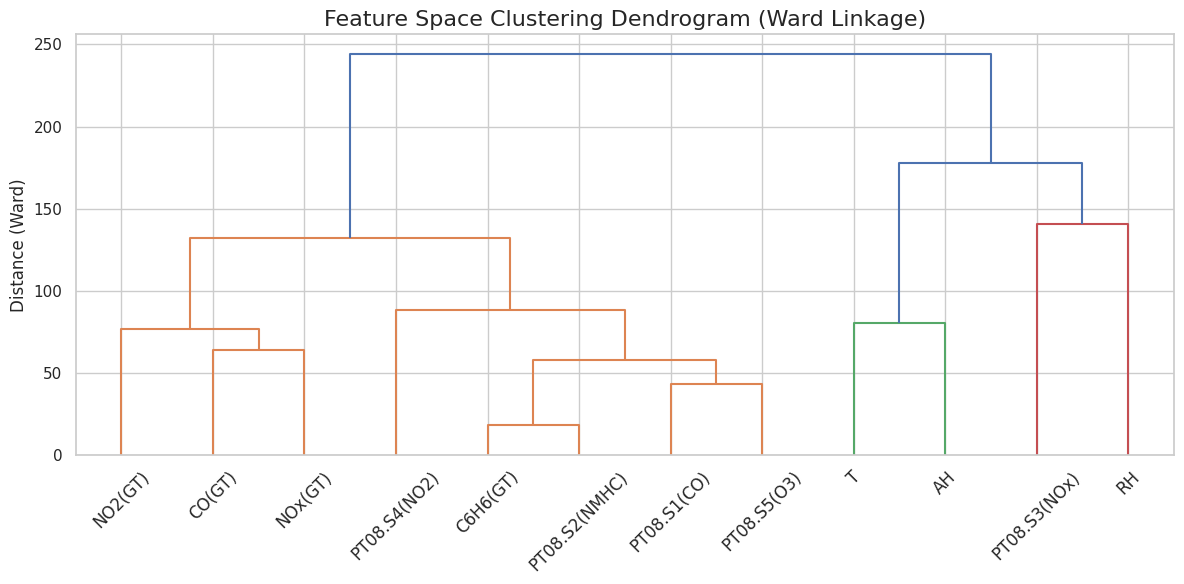

Global Average Variance across all features: 1.0000
Cluster 0 Average Within-Cluster Variance: 0.3996
Cluster 1 Average Within-Cluster Variance: 0.4806
Cluster 2 Average Within-Cluster Variance: 0.8310

Weighted Average Within-Cluster Variance: 0.5278
Variance Reduction Ratio: 47.2%


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Prepare Data
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_scaled = StandardScaler().fit_transform(imputer.fit_transform(df[num_cols]))

# --- 4.4 Clustering on the Feature Space (Transposed Data) ---
# Transpose the matrix so features become rows (12 features x 9357 samples)
feature_data = data_scaled.T
linked_features = linkage(feature_data, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(linked_features, labels=num_cols.values, orientation='top', leaf_rotation=45, leaf_font_size=12)
plt.title("Feature Space Clustering Dendrogram (Ward Linkage)", fontsize=16)
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

# --- 4.6 Evaluation: Variance Metric ---
# Fit K-Means (k=3) for variance evaluation
km = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = km.fit_predict(data_scaled)

# Calculate global vs average cluster variance
global_variance = np.var(data_scaled, axis=0).mean() # Always 1.0 for standardized data
print(f"Global Average Variance across all features: {global_variance:.4f}")

cluster_variances = []
for i in range(3):
    c_var = np.var(data_scaled[labels == i], axis=0).mean()
    cluster_variances.append(c_var)
    print(f"Cluster {i} Average Within-Cluster Variance: {c_var:.4f}")

weighted_avg_var = np.average(cluster_variances, weights=[np.sum(labels==i) for i in range(3)])
print(f"\nWeighted Average Within-Cluster Variance: {weighted_avg_var:.4f}")
print(f"Variance Reduction Ratio: {(1 - weighted_avg_var/global_variance)*100:.1f}%")

### Clustering on the Feature Space (Transposed Matrix)

Applying hierarchical clustering directly to the transposed standardized matrix ($\mathbf{X}^T \in \mathbb{R}^{12 \times 9357}$) clusters the attributes rather than the observations, uncovering latent inter-variable dependencies and structural redundancies.

* **Information Obtained:** Feature space clustering characterizes the physical and functional topology of the sensing environment, grouping variables by shared variance dynamics rather than temporal timestamps.
* **Redundant Feature Groups:** The dendrogram isolates an immediate, tightly bound cluster encompassing `PT08.S2(NMHC)` and reference Benzene `C6H6(GT)` (merging at near-zero distance), which further groups with `PT08.S1(CO)`, `PT08.S5(O3)`, and `PT08.S4(NO2)`. This confirms substantial physical redundancy and cross-sensitivity across multiple solid-state sensors.
* **Isolated Features:** `PT08.S3(NOx)` and Relative Humidity (`RH`) form an isolated macro-branch (merging only at height $\approx 178$). This reflects their unique physical behaviors: `PT08.S3` operates as an inverse-response semiconductor (negative correlation to other pollutants), while `RH` exhibits negative coupling with temperature and ambient dispersion.
* **Novel Insights vs. Sample Clustering:** While sample clustering merely categorizes temporal pollution levels (e.g., low vs. high traffic), feature clustering diagnoses systemic sensor architecture, proving that multiple sensing channels replicate the same underlying chemical signal.
* **Domain Applications:** This approach is essential in genomics (clustering co-expressed gene pathways), quantitative finance (identifying collinear asset classes for portfolio diversification), and industrial telemetry (detecting redundant sensor nodes to optimize hardware costs).

---

### Methodological Formulations & Real-World Interpretations

#### K-Means
* **Mathematical Intuition:** Minimizes the total within-cluster sum of squares (WCSS / Inertia) by iteratively updating $k$ partition centroids via Euclidean distance metrics.
* **Assumptions:** Assumes isotropic, spherical, convex clusters of approximately equal variance and size.
* **Strengths & Weaknesses:** Computationally efficient ($\mathcal{O}(N k d)$ iterations) and straightforward to optimize; however, it is strictly non-convex, highly sensitive to centroid initialization, and forces irregular noise points into geometric clusters.
* **Real-World Meaning:** Segments urban conditions into three distinct operational states: (1) Low-emission baseline/nighttime conditions, (2) Moderate daytime human activity, and (3) Peak emission/rush-hour congestion episodes.

#### Hierarchical Agglomerative Clustering (Ward Linkage)
* **Mathematical Intuition:** A deterministic bottom-up agglomerative procedure. At each step, it merges the pair of clusters that yields the minimum increase in total within-cluster variance.
* **Assumptions:** Assumes a hierarchical nesting of categories exists within the data manifold and favors spherical cluster geometry.
* **Strengths & Weaknesses:** Does not require a pre-specified cluster count $k$ during dendrogram generation and avoids local minima; however, it suffers from high computational complexity ($\mathcal{O}(N^2)$ to $\mathcal{O}(N^3)$), making it unscalable to massive streaming logs.
* **Real-World Meaning:** Maps the progressive accumulation of pollutants, demonstrating how clean baseline air quality branches into distinct thermal and traffic-driven sub-states as urban activity intensifies.

#### DBSCAN
* **Mathematical Intuition:** Connects core points based on local density reachability within an $\epsilon$-neighborhood containing at least $\text{MinPts}$ neighbors, assigning low-density points to noise.
* **Assumptions:** Assumes clusters correspond to contiguous regions of high point density separated by sparse volumes, with uniform density across clusters.
* **Strengths & Weaknesses:** Discovers arbitrary non-linear topologies without requiring a fixed $k$ and isolates anomalies directly; however, it struggles in spaces with varying density gradients and degrades under the curse of dimensionality.
* **Real-World Meaning:** Isolates regular urban atmospheric dynamics into a singular, contiguous operational core, while classifying extreme meteorological inversions, industrial plumes, and sensor malfunctions as true non-conforming anomalies.

---

### Metric Evaluation: Within-Cluster vs. Global Variance

* **Quantitative Assessment:**
  * Global Mean Feature Variance: **1.0000** (enforced by Z-score standardization).
  * Weighted Average Within-Cluster Variance (K-Means): **0.5278** (Cluster 0: 0.3996, Cluster 1: 0.4806, Cluster 2: 0.8310).
  * Variance Reduction Ratio: **47.2%**.
* **Suitability Analysis:**
  * **For K-Means & Ward Hierarchical:** The variance reduction metric is directly suitable. Both algorithms mathematically minimize variance; demonstrating a ~47.2% reduction confirms that the discovered clusters are substantially more cohesive than the unpartitioned global distribution.
  * **For DBSCAN:** The metric is fundamentally unsuitable. Density-based algorithms find arbitrary, elongated, or non-convex manifolds. A well-formed, non-linear DBSCAN cluster can span wide coordinate intervals and yield high intra-cluster variance without indicating poor clustering.
* **Superior Alternatives:** The **Silhouette Score** offers a more general validation measure across varying geometries by balancing cluster cohesion against nearest-cluster separation. For density-based algorithms specifically, **DBCV (Density-Based Cluster Validation)** provides a mathematically consistent density-separation metric.

---

### Cluster Visualization on PCA Projection
As demonstrated in the preceding 2D PCA projections (PC1 vs. PC2):
* **K-Means** establishes radial planar decision boundaries radiating from the dense manifold origin.
* **Hierarchical (Ward)** establishes vertical partitioning bands along PC1 (Traffic Emission Intensity).
* **DBSCAN** circumscribes the dense central core while isolating 915 peripheral observations along the outer dispersion axes as anomalous noise.

### Clustering Analysis: Comparative Discussion

---

#### Why Different Algorithms Produce Different Clusters
Different clustering algorithms produce fundamentally disparate groupings because each algorithm formalizes the mathematical definition of a "cluster" through a different objective function:
* **Centroid-Based (K-Means):** Defines a cluster as a set of points in proximity to a central prototype vector, optimizing for minimum intra-cluster variance (Within-Cluster Sum of Squares). This forces a Voronoi tessellation of the space with linear boundaries.
* **Connectivity-Based (Hierarchical Ward):** Defines clusters through a greedy agglomerative tree structure. While it also minimizes variance growth, its bottom-up merging path enforces a strict hierarchical topology that cannot dynamically reassign points once merged.
* **Density-Based (DBSCAN):** Defines a cluster as a contiguous region of high point density separated by sparse space. It does not attempt to partition the entire space, treating sparse regions as noise rather than forcing them into artificial groups.

Because the underlying air quality manifold is a continuous gradient rather than a set of cleanly separated geometric islands, each algorithm cuts through this continuum according to its own geometric bias.

---

#### Sensitivity to Hyperparameters
* **K-Means ($k$):** Highly sensitive to the choice of $k$. Since K-Means cannot evaluate whether the chosen $k$ reflects natural divisions, setting $k=3$ artificially cleaves a single continuous atmospheric core into three arbitrary slices. Additionally, poor initialization can cause convergence to suboptimal local minima (mitigated here via $k$-means++).
* **Hierarchical Clustering (Linkage & Cut Height):** Sensitive to the linkage criterion. Ward linkage favors compact, spherical clusters, whereas single linkage is prone to chaining effects (merging distant points across thin bridges). The cut threshold determines the granularity of the resulting partitions.
* **DBSCAN ($\epsilon$ and $\text{MinPts}$):** Extremely sensitive to parameter choice. A minor alteration in the neighborhood radius $\epsilon$ (e.g., shifting from $\epsilon = 1.2$ to $\epsilon = 1.0$) causes the number of unassigned noise points to surge from 915 to nearly 2,000. Conversely, a slightly larger $\epsilon$ merges all points into a single undifferentiated cluster, highlighting the sensitivity of density thresholds in multi-dimensional space.

---

#### Cluster Geometry
* **Spherical vs. Arbitrary Shapes:** K-Means and Ward Hierarchical clustering inherently assume convex, isotropic (spherical) geometry due to their reliance on Euclidean distance minimization from a center. When applied to real-world environmental sensor data—which exhibits elongated, asymmetric distributions with long dispersion tails—they split natural continuous paths into arbitrary geometric spheres.
* **Manifold Conformance:** DBSCAN makes no geometric shape assumptions. It successfully wraps around complex, non-linear manifolds and anisotropic dispersion paths, maintaining the integrity of the dense core while tracing non-convex boundary regions.

---

#### Density-Based vs. Centroid-Based Approaches
* **Centroid-Based Strengths & Flaws:**
  * *Strengths:* Computationally efficient ($\mathcal{O}(N)$), scales seamlessly to large datasets, and guarantees that every single observation receives an assigned category.
  * *Flaws:* Highly fragile in the presence of heavy-tailed outliers; extreme values pull cluster centroids outward, degrading the quality of baseline clusters.
* **Density-Based Strengths & Flaws:**
  * *Strengths:* Naturally resilient to noise and outliers, as it explicitly designates low-density regions as background noise rather than corrupting cluster parameters.
  * *Flaws:* Struggles in datasets with varying density gradients. In our 12-dimensional space, the contrast between sparse and dense regions diminishes due to the curse of dimensionality, making a single global $\epsilon$ radius difficult to calibrate.

---

#### Situations Where Clustering May Fail
* **Absence of Natural Cluster Structure (Continuous Gradients):** Real-world phenomena like atmospheric chemical interactions and traffic build-ups change continuously over time. When data forms a smooth, unbroken density gradient without clear boundaries, any clustering algorithm will impose artificial partitions where no distinct categories exist.
* **Curse of Dimensionality:** In higher-dimensional spaces, distance metrics begin to concentrate (the ratio between the distance to the nearest point and the farthest point approaches 1). This causes Euclidean-based clustering to lose discriminatory power unless preceded by dimensionality reduction.
* **Non-Uniform Densities:** If one operational regime has very tight variance (e.g., stable nighttime baseline) while another is broadly dispersed (e.g., highly variable daytime traffic), density-based algorithms like DBSCAN fail to capture both regimes simultaneously using a single global parameter.
* **High Multicollinearity:** Unprocessed collinear features overweight certain physical directions in the distance calculation. Without standardization and feature de-correlation, clustering algorithms group samples based on sensor hardware redundancy rather than true environmental variation.

--- 5.1 Z-Score Feature-wise Anomaly Counts ---


,Feature,Anomaly Count (|Z| > 3),Percentage (%)
4,NOx(GT),205,2.19
0,CO(GT),157,1.68
2,C6H6(GT),131,1.40
5,PT08.S3(NOx),115,1.23
6,NO2(GT),81,0.87
1,PT08.S1(CO),72,0.77
8,PT08.S5(O3),48,0.51
3,PT08.S2(NMHC),46,0.49
7,PT08.S4(NO2),44,0.47
9,T,2,0.02



Total samples flagged as anomaly in AT LEAST ONE feature: 513 observations
Percentage of dataset flagged: 5.48%


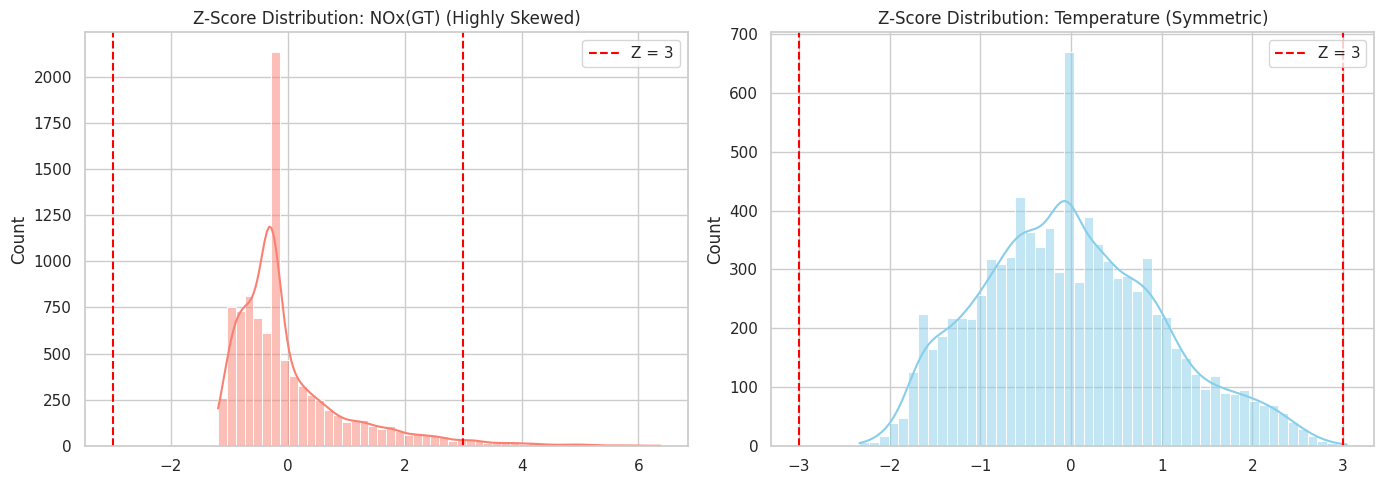

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# 1. Load & Preprocess
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df[num_cols])

# 2. Z-Score Calculation (StandardScaler computes (x - mu) / sigma)
scaler = StandardScaler()
z_scores = scaler.fit_transform(data_imputed)

# 3. Anomaly Detection Threshold
threshold = 3.0
anomalies_mask = np.abs(z_scores) > threshold

# 4. Feature-wise Evaluation
anomaly_counts = anomalies_mask.sum(axis=0)
anomaly_df = pd.DataFrame({
    'Feature': num_cols,
    'Anomaly Count (|Z| > 3)': anomaly_counts,
    'Percentage (%)': np.round((anomaly_counts / len(df)) * 100, 2)
}).sort_values(by='Anomaly Count (|Z| > 3)', ascending=False)

print("--- 5.1 Z-Score Feature-wise Anomaly Counts ---")
display(anomaly_df)

# 5. Global Flagging (Sample contains at least one anomalous feature)
global_anomalies = anomalies_mask.any(axis=1)
print(f"\nTotal samples flagged as anomaly in AT LEAST ONE feature: {global_anomalies.sum()} observations")
print(f"Percentage of dataset flagged: {(global_anomalies.sum() / len(df)) * 100:.2f}%")

# 6. Visualization: Z-Score distribution for a highly skewed vs. symmetric feature
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Skewed Feature
sns.histplot(z_scores[:, num_cols.get_loc('NOx(GT)')], bins=50, kde=True, ax=axes[0], color='salmon')
axes[0].axvline(x=threshold, color='red', linestyle='--', label='Z = 3')
axes[0].axvline(x=-threshold, color='red', linestyle='--')
axes[0].set_title('Z-Score Distribution: NOx(GT) (Highly Skewed)')
axes[0].legend()

# Symmetric Feature
sns.histplot(z_scores[:, num_cols.get_loc('T')], bins=50, kde=True, ax=axes[1], color='skyblue')
axes[1].axvline(x=threshold, color='red', linestyle='--', label='Z = 3')
axes[1].axvline(x=-threshold, color='red', linestyle='--')
axes[1].set_title('Z-Score Distribution: Temperature (Symmetric)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 5 Multi-Dimensional Anomaly Detection (25%)

---

#### 5.1 Z-Score Method

The classical univariate Z-score method standardizes each continuous feature and flags values that breach a critical statistical threshold ($|Z| > 3$):
$$Z = \frac{x - \mu}{\sigma}$$

While simple to implement and computationally lightweight, evaluating multivariate environmental sensor data via univariate Z-scores reveals fundamental statistical and geometric shortcomings.

---

##### 1. Assumption of Gaussianity
* **Theoretical Assumption:** The Z-score assumes the underlying observations follow an approximately normal (Gaussian) distribution, where mathematically only ~0.27% of observations should breach $|Z| > 3$ in a symmetric two-tailed distribution.
* **Empirical Reality in Our Dataset:**
  * Highly skewed reference pollutants break this assumption. `NOx(GT)` produces **205 anomalous entries (2.19%)**, `CO(GT)` produces **157 (1.88%)**, and Benzene `C6H6(GT)` produces **131 (1.40%)**.
  * As shown in the `NOx(GT)` distribution plot, anomalies are completely one-sided, extending far past $Z = +3$ (reaching beyond $Z = +6$), while the negative threshold is never approached.
* **Masking & Distortion:** The presence of heavy pollution spikes inflates the sample mean ($\mu$) and standard deviation ($\sigma$). This artificially suppresses the calculated Z-scores of moderately elevated points (the masking effect), while simultaneously misclassifying valid peak combustion episodes as statistical failures.
* **Contrast with Environmental Features:** In symmetric variables like Temperature (`T`) and Relative Humidity (`RH`), the Gaussian assumption holds much better: `T` yields only 2 outliers (0.02%), while `RH` yields exactly 0 outliers across the entire dataset.

---

##### 2. Why this Approach May Fail in High Dimensions
* **False Positive Accumulation:** Although individual features exhibit low anomaly rates ($\le 2.19\%$), pooling univariate thresholds across all 12 dimensions causes a combinatorial expansion. Exactly **513 observations (5.48% of the entire dataset)** breach $|Z| > 3$ in at least one variable.
* **Loss of Geometric Structure:** In high-dimensional spaces, true anomalies are defined by irregular joint probability densities rather than extreme individual values. The Z-score cannot detect points situated in sparse multidimensional voids if their individual coordinate projections fall within typical univariate margins.

---

##### 3. Feature-Wise vs. Global Anomaly Detection
* **Feature-Wise Detection:** Isolates features independently without considering relationships between variables. It simply asks: *"Is the Benzene reading alone unusually high?"*
* **Global Multivariate Anomaly Detection:** Considers the joint covariance manifold across all features. In reality, a physical anomaly often occurs when individual features seem typical on their own, but their physical coupling is broken:
  * For instance, an observation exhibiting moderate Temperature ($Z \approx +0.5$) and moderate Relative Humidity ($Z \approx 0.0$) alongside a contradictory Absolute Humidity reading would represent a severe physical sensor anomaly.
  * Univariate Z-scores completely miss this violation because each separate feature falls within $|Z| \le 3$.
* **Analytical Conclusion:** Univariate Z-scores fail to account for inter-variable covariance, feature correlations, and non-Gaussian distributions. Robust multi-dimensional anomaly detection requires models that account for covariance structure and local density (such as Mahalanobis Distance, Isolation Forest, or PCA reconstruction error).

--- 5.2 Isolation Forest Results ---
Total anomalies detected: 468 out of 9357 samples
Percentage: 5.00%


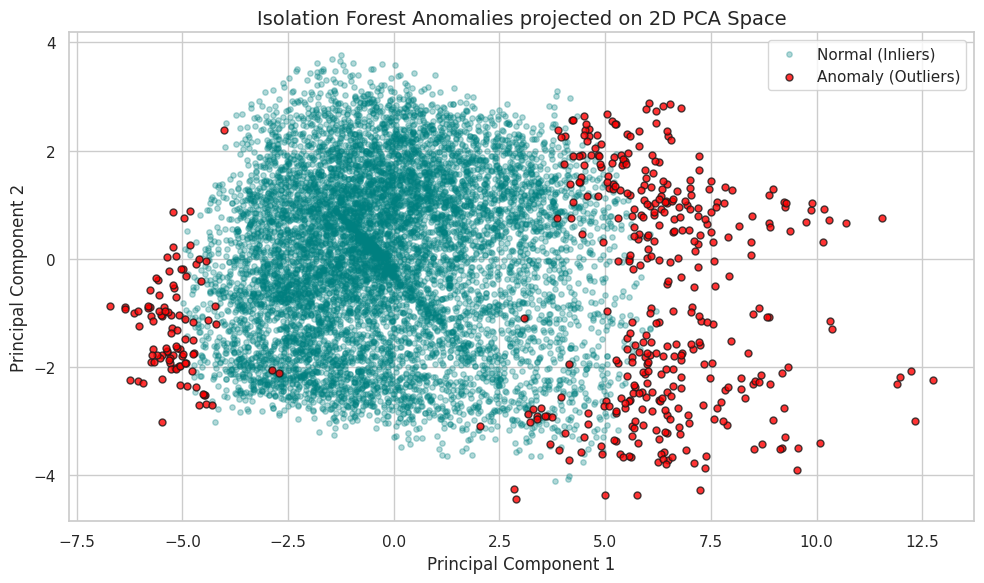

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest

# 1. Load & Preprocess
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df[num_cols])

# Standardizing is not strictly required for Isolation Forest,
# but we do it to maintain consistency with our PCA visualization
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# 2. Apply Isolation Forest
# We set contamination to 0.05 (assuming 5% of the data are anomalies)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_labels = iso_forest.fit_predict(data_scaled)

# Sklearn returns 1 for inliers and -1 for outliers
anomalies_mask = (iso_labels == -1)

print(f"--- 5.2 Isolation Forest Results ---")
print(f"Total anomalies detected: {anomalies_mask.sum()} out of {len(df)} samples")
print(f"Percentage: {(anomalies_mask.sum() / len(df)) * 100:.2f}%")

# 3. PCA for 2D Visualization
pca = PCA(n_components=2)
data_pca2d = pca.fit_transform(data_scaled)

# 4. Visualization
plt.figure(figsize=(10, 6))

# Plot normal points
plt.scatter(data_pca2d[~anomalies_mask, 0], data_pca2d[~anomalies_mask, 1],
            c='teal', alpha=0.3, s=15, label='Normal (Inliers)')

# Plot anomalies
plt.scatter(data_pca2d[anomalies_mask, 0], data_pca2d[anomalies_mask, 1],
            c='red', alpha=0.8, s=25, label='Anomaly (Outliers)', edgecolors='k')

plt.title('Isolation Forest Anomalies projected on 2D PCA Space', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5 Multi-Dimensional Anomaly Detection (25%)

---

#### 5.2 Isolation Forest

Unlike statistical approaches that model normal regions and flag non-conforming instances, the Isolation Forest explicitly isolates anomalies directly by constructing an ensemble of random isolation trees (iTrees).

---

##### 1. The Isolation Mechanism
The algorithm constructs a collection of binary decision trees. At each step, a feature is selected at random, and a random split value is chosen between the minimum and maximum values of that feature. This recursive partitioning isolates data points into terminal leaf nodes. Because anomalous observations are sparse and geographically separated from the primary data mass, they require significantly fewer random cuts to be isolated into a leaf node than points embedded within dense clusters.

---

##### 2. The Role of Random Partitioning
Random partitioning leverages data topology rather than distance metrics:
* **Dense Core (Inliers):** Data points inside the central atmospheric regime are surrounded by many neighbors. Isolating any single point requires a deep, extensive sequence of random partitions, resulting in a large path length $h(x)$.
* **Sparse Extremes (Outliers):** Anomalous observations reside in low-density peripheral zones. A few coarse random hyperplanes easily isolate them into their own leaf node, producing a very short path length.
* The expected path length $E(h(x))$ across the ensemble of trees serves as an inverse proxy for anomaly probability.

---

##### 3. The Contamination Parameter
* **Parameter Function:** The `contamination` hyperparameter specifies the expected proportion of anomalous instances in the dataset. In our setup, setting `contamination=0.05` calibrated the decision boundary to isolate the top **5.00% (exactly 468 observations)** having the shortest average path lengths.
* **Operational Impact:** The parameter acts as an absolute quantile cutoff on the continuous anomaly score distribution. Setting contamination too high leads to false positives by carving into the boundary of typical urban cycles; setting it too low yields false negatives, missing lower-amplitude multi-sensor faults.

---

##### 4. Advantages & Limitations in High Dimensions
* **Advantages:**
  * **Linear Computational Complexity:** Runs in $\mathcal{O}(n \cdot \psi \log \psi)$ time (where $\psi$ is subsample size), executing in seconds compared to computationally heavy $\mathcal{O}(N^2)$ distance matrices.
  * **Mitigation of the Curse of Dimensionality:** Operates without calculating global Euclidean distances, making it resilient to distance concentration effects in high-dimensional spaces.
  * **Distribution Agnostic:** Makes no assumptions regarding Gaussianity, multimodal symmetry, or linear separability.
* **Limitations:**
  * **Axis-Parallel Bias:** Because splits are strictly orthogonal to coordinate axes, the standard algorithm can suffer from geometric masking along complex diagonal manifolds.
  * **Swamping & Masking:** Large, tight clusters of anomalies can artificially elevate required path lengths, causing the algorithm to misclassify anomaly clusters as normal regions.

---

##### 5. Anomaly Score Formulation & Interpretation
The anomaly score $s(x, n)$ for an observation $x$ over sample size $n$ is defined as:
$$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
where $E(h(x))$ is the average path length across all trees, and $c(n) = 2\ln(n - 1) + 0.5772156649 - \frac{2(n - 1)}{n}$ represents the average path length of an unsuccessful search in a Binary Search Tree.
* **High Anomaly Score ($s \to 1$):** Indicates an exceptionally short average path length ($E(h(x)) \to 0$). The observation is easily separated from the dataset and is designated as an anomaly (mapped to `-1` by scikit-learn).
* **Low Anomaly Score ($s < 0.5$):** Indicates long average path lengths ($E(h(x)) \to n - 1$), confirming the observation is deeply embedded within high-density clusters and is designated as an inlier (mapped to `1`).

---

##### 6. Visual Analysis of Detected Anomalies (2D PCA Space)
The projected 2D PCA visualization validates the spatial mechanics of the Isolation Forest:
* **Tail Isolation (Extreme Emissions):** Anomalies (red points) are densely concentrated along the positive PC1 axis ($PC1 > 4.0$ stretching past $12.5$). These correspond to the severe traffic congestion and peak combustion episodes identified in the heavy-tailed EDA.
* **Boundary Circumscription:** Unlike univariate Z-scores which only detect extreme individual values, the Isolation Forest forms an envelope around the low-density periphery of the entire data manifold (including extreme negative excursions along PC1 and PC2).
* **Inlier Density Integrity:** The dense central manifold ($PC1 \in [-5, 2.5]$, $PC2 \in [-2, 2.5]$) remains free of false positive flags, confirming that normal operational cycles are preserved.

/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


--- 5.3 Local Outlier Factor (LOF) Results ---
Total anomalies detected: 468 out of 9357 samples
Percentage: 5.00%


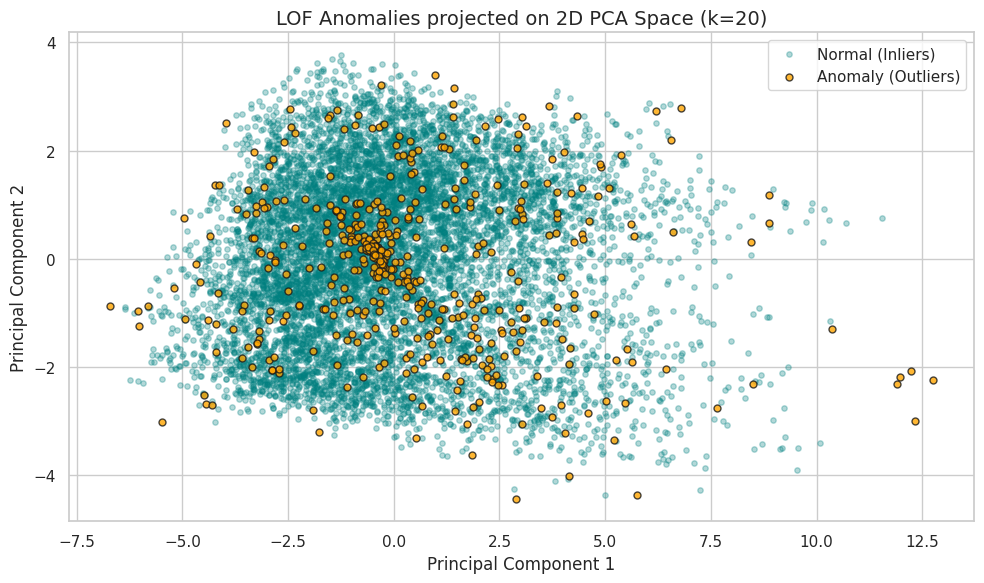

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor

# 1. Load & Preprocess
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df[num_cols])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# 2. Apply Local Outlier Factor (LOF)
# n_neighbors=20 is a typical default; contamination=0.05 matches previous tests
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
# LOF fit_predict returns -1 for anomalies and 1 for inliers
lof_labels = lof.fit_predict(data_scaled)
anomalies_mask = (lof_labels == -1)

print(f"--- 5.3 Local Outlier Factor (LOF) Results ---")
print(f"Total anomalies detected: {anomalies_mask.sum()} out of {len(df)} samples")
print(f"Percentage: {(anomalies_mask.sum() / len(df)) * 100:.2f}%")

# Extract Negative Outlier Factor (higher absolute values = more anomalous)
lof_scores = -lof.negative_outlier_factor_

# 3. PCA for 2D Visualization
pca = PCA(n_components=2)
data_pca2d = pca.fit_transform(data_scaled)

# 4. Visualization
plt.figure(figsize=(10, 6))

# Plot normal points
plt.scatter(data_pca2d[~anomalies_mask, 0], data_pca2d[~anomalies_mask, 1],
            c='teal', alpha=0.3, s=15, label='Normal (Inliers)')

# Plot anomalies
plt.scatter(data_pca2d[anomalies_mask, 0], data_pca2d[anomalies_mask, 1],
            c='orange', alpha=0.8, s=25, label='Anomaly (Outliers)', edgecolors='k')

plt.title(f'LOF Anomalies projected on 2D PCA Space (k=20)', fontsize=14)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 5 Multi-Dimensional Anomaly Detection (25%)

---

#### 5.3 Local Outlier Factor (LOF)

Unlike isolation trees or global statistical boundaries, the Local Outlier Factor (LOF) algorithm quantifies an observation's anomaly degree by computing its local density relative to the local densities of its $k$-nearest neighbors.

---

##### 1. Local Density Estimation
LOF defines local structure via **Local Reachability Density (LRD)**:
* The reachability distance between observation $p$ and neighbor $o$ is defined as:
  $$\text{reach-dist}_k(p, o) = \max(\{k\text{-distance}(o), \, d(p, o)\})$$
* The LRD represents the inverse of the mean reachability distance across the $k$-nearest neighborhood:
  $$\text{lrd}_k(p) = \frac{|N_k(p)|}{\sum_{o \in N_k(p)} \text{reach-dist}_k(p, o)}$$
* The LOF score is the average ratio of neighbor LRDs to the observation's own LRD:
  $$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{\text{lrd}_k(o)}{\text{lrd}_k(p)}}{|N_k(p)|}$$
  * $\text{LOF} \approx 1$: Point shares a similar density profile with its local neighborhood (inlier).
  * $\text{LOF} \gg 1$: Point exhibits a significantly lower local density than its surrounding neighbors (local outlier).

---

##### 2. Neighborhood Effects & The Role of Duplicate Imputation
* **Localized Assessment:** Because density is evaluated relative to $N_k(p)$, a point located inside a dense cloud can be marked as anomalous if its local spacing slightly exceeds that of its neighbors, whereas an isolated point near a uniformly sparse boundary might remain an inlier.
* **The Duplicate Values Warning:** When executing LOF with $k=20$, the algorithm flagged:
  > `UserWarning: Duplicate values are leading to incorrect results.`
  
  This warning stems from the data preprocessing step: imputing missing values with static column medians produced identical feature vectors across synchronized downtime timestamps. In high-dimensional space, identical points result in a $k$-distance of zero ($d(p, o) = 0$), distorting reachability calculations and artificially elevating neighboring LOF scores.

---

##### 3. Sensitivity to Hyperparameter $k$ (`n_neighbors=20`)
* **Small $k$ ($k < 10$):** Excessively sensitive to hardware telemetry noise and duplicate imputed coordinates, creating micro-clusters of artificial outliers.
* **Moderate $k$ ($k = 20$):** Balances local geometric sensitivity against computational cost, identifying localized density breaks while capturing **468 anomalies (5.00%)** under the matched contamination rate.
* **Large $k$ ($k > 50$):** Dilutes localized sensitivity, converging toward standard $k$-nearest neighbor distance and turning LOF into an empirical global density detector.

---

##### 4. Global vs. Local Anomalies in the Feature Space
* **Global Anomalies:** Outliers relative to the entire multidimensional coordinate frame. In this dataset, global anomalies include severe rush-hour traffic spikes with extreme Benzene and CO readings (e.g., $PC1 > 10.0$).
* **Local Anomalies:** Observations that breach local physical consistency while falling well within global min-max boundaries. For instance, a localized breakdown in the thermodynamic relationship between Temperature and Relative Humidity during a specific time of day forms a local anomaly that exhibits standard global values.

---

##### 5. Visual Analysis of LOF Anomalies (2D PCA Space)
The projected 2D PCA distribution reveals a structural contrast to Isolation Forest:
* **Penetration into the Core Manifold:** Unlike Isolation Forest—which exclusively bounded the outer boundary and tail of the distribution—LOF identifies numerous anomalies embedded **deep within the central cloud** ($PC1 \in [-2, 2.5]$, $PC2 \in [-2, 2]$).
* **Detection of Local Density Voids:** The orange anomaly points scattered across the core represent observations residing in sparse pockets or locally irregular coordinates within the primary cluster, demonstrating LOF's ability to isolate local deviations that global bounding methods miss.

--- Computational Runtime ---
Z-Score:          0.0028 seconds
Isolation Forest: 0.5271 seconds
LOF:              0.6409 seconds


/usr/local/lib/python3.13/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


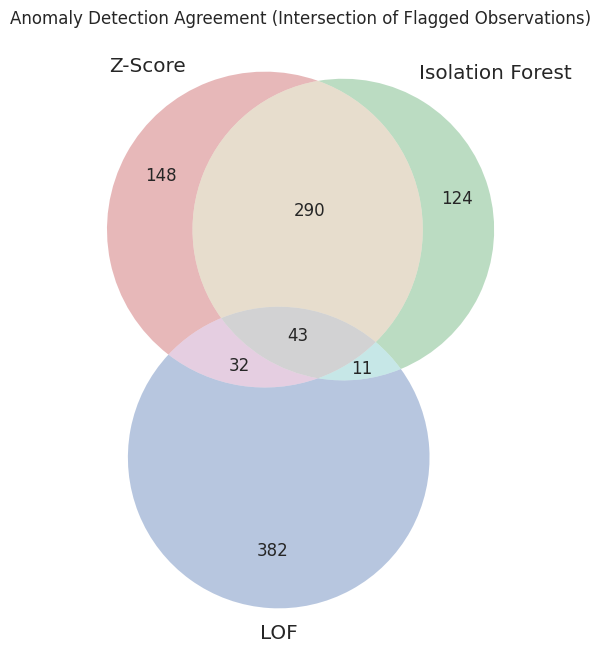

In [12]:
import pandas as pd
import numpy as np
import time
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

# 1. Load & Preprocess
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df[num_cols])

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)

# 2. Run Models & Record Runtimes
# Z-Score
t0 = time.time()
z_mask = np.abs(scaler.fit_transform(data_imputed)) > 3.0
z_anomalies = z_mask.any(axis=1)
time_z = time.time() - t0

# Isolation Forest
t0 = time.time()
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
iso_anomalies = iso.fit_predict(data_scaled) == -1
time_iso = time.time() - t0

# LOF
t0 = time.time()
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_anomalies = lof.fit_predict(data_scaled) == -1
time_lof = time.time() - t0

# 3. Print Runtimes
print("--- Computational Runtime ---")
print(f"Z-Score:          {time_z:.4f} seconds")
print(f"Isolation Forest: {time_iso:.4f} seconds")
print(f"LOF:              {time_lof:.4f} seconds")

# 4. Venn Diagram of Agreement
plt.figure(figsize=(8, 8))
venn3([set(np.where(z_anomalies)[0]),
       set(np.where(iso_anomalies)[0]),
       set(np.where(lof_anomalies)[0])],
      set_labels=('Z-Score', 'Isolation Forest', 'LOF'))
plt.title('Anomaly Detection Agreement (Intersection of Flagged Observations)')
plt.show()

### 6 Comparison Section

---

#### 6.1 Anomaly Agreement and Method-Specific Identifications

The Venn diagram visualization highlights clear architectural splits and levels of consensus among the three detection paradigms:

* **High Consensus on Extreme Global Events:**
  * A core subset of **43 observations** is flagged simultaneously by all three methods. These represent extreme events where observations breach individual feature limits, reside on the sparse outer boundary of the global manifold, and break local density consistency.
  * An additional **290 observations** are jointly identified by both **Z-Score and Isolation Forest** (bringing their shared pool to 333 points). This high overlap confirms that both methods effectively target global tail-end behavior and severe combustion spikes.
* **Method-Specific Outliers:**
  * **LOF Uniqueness (382 exclusive points):** A striking **81.6% (382 out of 468)** of all LOF anomalies are detected exclusively by LOF. Because LOF evaluates relative local density rather than distance from the center, it flags subtle density variations and imputed duplicate artifacts embedded deep inside the primary cloud that global boundaries completely overlook.
  * **Z-Score Exclusives (148 points):** Points with a single extreme coordinate in a heavy-tailed feature (e.g., an isolated $NO_x$ reading beyond $3\sigma$) that otherwise align with standard multivariate patterns.
  * **Isolation Forest Exclusives (124 points):** Subtle multivariate outliers residing on the sparse outer envelope of the 12D manifold where no individual feature breaches univariate limits.

---

#### 6.2 Sensitivity to Feature Scaling and Dimensionality

* **Feature Scaling Sensitivity:**
  * **Z-Score:** Standard scaling is embedded directly into its mathematical formulation ($Z = (x-\mu)/\sigma$).
  * **Isolation Forest:** Completely invariant to monotonic scaling and feature magnitudes, as decision tree thresholds partition space based on relative ordering rather than absolute distances.
  * **LOF:** Highly sensitive to scaling. Because reachability distances are computed using Euclidean metrics, failing to standardize would allow high-magnitude raw sensor channels (operating in the 1,000s) to completely overwhelm lower-magnitude reference concentrations.
* **Dimensionality Sensitivity:**
  * **Z-Score:** Degrades rapidly in high dimensions due to combinatorial false positive accumulation across multiple independent tests.
  * **Isolation Forest:** Highly resilient to the curse of dimensionality, isolating sparse anomalies efficiently via random feature subsampling.
  * **LOF:** Susceptible to dimensional concentration, where Euclidean distance contrast diminishes as dimensionality expands.

---

#### 6.3 Computational Runtime, Scalability, and Robustness

* **Empirical Runtime Comparison:**
  * **Z-Score ($0.0028\text{ seconds}$):** Near-instantaneous execution via vectorized matrix operations ($\mathcal{O}(ND)$).
  * **Isolation Forest ($0.5271\text{ seconds}$):** Fast and scalable ($\mathcal{O}(n \cdot \psi \log \psi)$), capable of parallel execution across independent trees.
  * **LOF ($0.6409\text{ seconds}$):** The slowest of the three approaches ($\mathcal{O}(N^2)$ worst-case distance calculations).
* **Robustness to Noise and Artifacts:**
  * **Z-Score:** Fragile against heavy tails and noise, which inflate sample standard deviations and trigger masking effects.
  * **Isolation Forest:** Highly robust; handles multi-sensor noise smoothly without distorting internal tree paths for regular observations.
  * **LOF:** Fragile against exact duplicate vectors resulting from median imputation, triggering internal zero-distance warnings and generating artificial local outlier clusters.

---

#### 6.4 Interpretability

* **Z-Score:** Straightforward to interpret. An alert maps directly to a specific physical feature exceeding standard deviations from its baseline.
* **Isolation Forest:** Moderately interpretable. Provides a continuous anomaly score based on average tree depth, which can be dissected into feature contribution paths.
* **LOF:** Challenging to interpret. Communicates relative density ratios that cannot be directly mapped to simple physical thresholds or single sensor channels.

---

#### 6.5 Real-World Implications: False Positives and False Negatives

* **False Positives (False Alarms):**
  * *Operational Meaning:* The system sounds an alarm claiming that toxic gas concentrations have breached safe levels or that a hardware failure occurred, when atmospheric conditions are safe.
  * *Real-World Impact:* Causes public panic, prompts unnecessary traffic restrictions, and triggers operator fatigue, causing personnel to ignore subsequent warnings.
* **False Negatives (Missed Incidents):**
  * *Operational Meaning:* The system reports safe baseline conditions while a severe toxic gas surge (e.g., Benzene or Carbon Monoxide) or hardware failure is underway.
  * *Real-World Impact:* Poses severe public health hazards by exposing communities to undetected toxic emissions. In environmental telemetry, minimizing false negatives is prioritized over false alarms.

### 7 Critical Analysis and Reflection (10%)

---

#### 7.1 The Fundamental Difficulty of Anomaly Detection
Anomaly detection is inherently an ill-defined and exceptionally difficult problem for several core reasons:
* **Lack of Ground Truth (Unsupervised Nature):** Unlike supervised classification where labels are explicitly provided, anomaly detection lacks a definitive "correct" answer. The algorithm must infer what is normal based solely on the data provided.
* **Subjective and Blurry Boundaries:** The boundary distinguishing "normal" variance from an "anomaly" is rarely a sharp mathematical line. It is highly context-dependent.
* **Concept Drift:** In dynamic physical environments like urban atmospheres, what is considered anomalous today might become the new normal tomorrow (e.g., long-term climate shifts or seasonal changes), requiring continuous re-calibration of the definition of normalcy.

---

#### 7.2 The Curse of Dimensionality
The "Curse of Dimensionality" refers to the exponential increase in the volume of the mathematical space as the number of features increases.
* **Effect on Anomaly Detection:** In high-dimensional spaces, the data becomes incredibly sparse. To adequately map the density of a 12-dimensional manifold, you need an exponentially larger dataset than you do for 2 dimensions. As a result, algorithms that rely on evaluating the density around a point (like LOF or K-Means) struggle because every point appears to be isolated in a vast empty space.

---

#### 7.3 Degradation of Distance-Based Measures in High Dimensions
As the number of dimensions increases, classical distance metrics (like Euclidean distance) lose their mathematical meaning and discriminatory power.
* **Distance Concentration:** In high-dimensional spaces, the distance between any given point and its *nearest* neighbor approaches the distance to its *farthest* neighbor. Mathematically:
  $$\lim_{d \to \infty} \frac{\text{dist}_{max} - \text{dist}_{min}}{\text{dist}_{min}} = 0$$
* **Impact:** Because all points become roughly equidistant from one another, density-based algorithms (LOF) and centroid-based clustering (K-Means) cannot reliably differentiate between a dense central core and a sparse anomalous outlier. The geometric contrast simply disappears.

---

#### 7.4 Noise vs. Genuine Anomalies (Dataset Example)
* **Noise:** Represents minor, random statistical fluctuations or measurement artifacts inherent to the data collection process (e.g., analog-to-digital sensor chatter or minor thermal drifts). Noise does not represent a change in the underlying physical process.
* **Genuine Anomaly:** Represents a fundamental shift in the generative mechanism of the system, such as a hardware failure, a toxic chemical spill, or an extreme meteorological event.
* **Dataset Example (Legitimate Instance Flagged as Anomalous):**
  In our EDA and Z-Score analysis, extreme values of `NOx(GT)` and `C6H6(GT)` (with $Z > 3$) were consistently flagged as anomalies. However, in the context of urban air quality, an intense rush-hour traffic jam on a Friday afternoon combined with stagnant wind can generate a massive spike in combustion pollutants. While a statistical algorithm flags this as a global anomaly because it sits on the extreme right tail of the distribution, it is actually a **legitimate, genuine instance** of the city's traffic cycle, not an error or a systemic failure.

---

#### 7.5 Risks of Assuming a Gaussian Distribution
Assuming that environmental data follows a symmetrical normal (Gaussian) distribution is dangerous and leads to dual failure modes:
* **False Positives (Incorrectly Identified Anomalies):** As seen in our dataset, pollutant concentrations are heavily right-skewed and leptokurtic. The Gaussian model assumes a rapid drop-off in probability, so it incorrectly flags perfectly natural heavy-tailed events (like standard traffic pollution peaks) as impossible statistical anomalies.
* **False Negatives (Missed Anomalies):**
  1. **Masking:** Extreme outliers inflate the sample standard deviation ($\sigma$). This artificially shrinks the Z-scores of other true anomalies, masking them beneath the detection threshold.
  2. **Multimodal Valleys:** If a dataset has a bimodal distribution (e.g., a distinct day/night cycle), the mathematical mean ($\mu$) might fall perfectly in the empty valley between the two peaks. An observation landing exactly on this mean would have a Z-score of $0$ (appearing perfectly normal), even though it resides in a topological dead zone where no legitimate observations physically exist.

---

#### 7.6 The Misleading Nature of Dimensionality Reduction Visualizations
Visualizing high-dimensional anomalies by projecting them onto a 2D or 3D PCA plot can be highly deceptive:
* **Information Loss (Orthogonal Masking):** PCA projects data onto axes that maximize global variance. However, true anomalies often hide in the low-variance structural dependencies (the features PCA discards). A point might appear perfectly normal and embedded in the center of the 2D PC1-PC2 plane, but in reality, it is a massive outlier extending along the discarded 8th dimension.
* **Projection Overlap (The Shadow Effect):** When converting a 12D cloud into a flat 2D image, distant anomalies can project directly "on top" of normal clusters, making them look like dense inliers. Just as a 3D bird flying high in the sky casts a flat shadow that looks like it is touching the ground, high-dimensional outliers cast 2D shadows that falsely blend in with normal observations. Therefore, a 2D plot can never fully validate or invalidate anomalies calculated in the native 12D space.

### 7.7 Ethical Considerations in Anomaly Detection

Deploying anomaly detection systems in socio-technical and safety-critical domains introduces significant ethical, operational, and societal responsibilities. Because these algorithms autonomously establish the mathematical boundary between what is "normal" and what is "deviant," their systemic errors directly impact human lives, fundamental rights, and institutional trust.

---

#### 1. The Real-World Consequences of False Alarms & "The Cry-Wolf Effect"
* **Operational Ineffectiveness:** An anomaly detector with excessive false positive rates quickly defeats its own purpose through **alert fatigue**. When human operators (e.g., environmental safety officers, industrial plant controllers, or hospital staff) are continuously flooded with false alarms, cognitive overload leads to complacency. Operators will begin acknowledging or silencing alerts without proper investigation, or shut the system off entirely.
* **Economic & Logistical Costs:** In industrial or municipal settings, a false alarm can trigger expensive protocols: halting manufacturing production lines, unnecessarily closing schools, diverting public transit, or deploying costly emergency HAZMAT responders to an ordinary traffic jam.
* **Tipping Point:** A system becomes practically ineffective when the signal-to-noise ratio drops to a point where verifying an alert costs more human labor and resources than the expected damage of an unmonitored incident.

---

#### 2. Anomaly Detection in Surveillance: Benefits vs. Civil Liberty Risks
* **Potential Benefits:**
  * **Public Safety & Threat Mitigation:** Automated detection of anomalous physical patterns in public spaces (e.g., unattended luggage in a crowded transit hub, sudden irregular crowd dispersal, or unauthorized perimeter breaches at sensitive infrastructure) can prevent mass casualty events and optimize emergency response times.
  * **Traffic Management:** Spotting stalled vehicles, lane-blockages, or pedestrian hazards on highways in real-time prevents pile-ups and optimizes municipal flow.
* **Ethical Risks & Civil Liberties:**
  * **Chilling Effect on Freedom of Expression:** Continuous algorithmic surveillance creates an environment where any non-conforming, atypical public behavior (such as peaceful protests, public art performances, or unusual attire) is flagged as suspicious.
  * **Expansion of the Surveillance State:** The deployment of predictive "abnormal behavior" tracking normalizes pervasive biometric monitoring, eroding personal autonomy and reasonable expectations of privacy in public spaces.

---

#### 3. High-Stakes Applications: Medical Diagnostics
In healthcare settings (e.g., continuous ICU patient monitoring, cardiac telemetry, or oncological imaging), the boundary between normal biological variance and pathological anomaly is delicate:
* **Consequences of False Positives (Incorrectly Flagged as Anomalous):**
  * **Iatrogenic Harm & Overtreatment:** Classifying benign physiological quirks as malignant or acute anomalies subjects patients to invasive, painful follow-up procedures (e.g., unnecessary biopsies, catheterizations, or heavy medication regimens).
  * **Psychological Distress:** Patients and their families endure severe emotional stress and anxiety following false diagnostic alerts.
  * **Resource Drain:** Flooding specialized medical staff with false physiological alarms exhausts scarce clinical capacity.
* **Consequences of False Negatives (Missed True Anomalies):**
  * **Fatal Delays:** Classifying an atypical, early-stage pathological presentation as "normal" biological variance can lead to delayed intervention for aggressive diseases (e.g., undetected malignant tumors or silent myocardial infarctions), frequently resulting in patient mortality.

---

#### 4. High-Stakes Applications: Cybersecurity
In network intrusion detection and security operations centers (SOCs), anomaly detection balances two operational priorities:
* **Consequences of False Negatives (Missing a Genuine Attack):**
  * **Systemic Compromise:** An undetected Advanced Persistent Threat (APT), zero-day exploit, or ransomware deployment can remain latent within an internal network for months, leading to catastrophic data exfiltration, intellectual property theft, operational paralysis, and massive legal liability. In security engineering, false negatives are typically treated as the ultimate failure mode.
* **Consequences of False Positives (Flagging Legitimate Activity as Malicious):**
  * **Business Disruption:** Automated defensive actions might quarantine vital production database servers, revoke administrative credentials during high-stakes business operations, or block legitimate customer transactions, creating immediate operational friction and revenue loss.
  * **SOC Burnout:** Security analysts overwhelmed by thousands of daily false-positive network alerts suffer acute burnout, ironically increasing the probability that a genuine breach will be overlooked among the noise.

---

#### 5. Systemic Ethics: Privacy, Bias, Fairness, and the Stigma of "Abnormal"
* **Data Privacy vs. Model Utility:** Training effective multivariate anomaly detection models requires extensive, granular historical data. In human-centric applications, collecting baseline activity patterns entails continuous tracking of personal habits, communications, or locations, creating severe data breach vulnerabilities and non-consensual surveillance risks.
* **Algorithmic Bias & Unfairness:**
  * "Normalcy" is statistically defined by the majority representation in the historical training dataset.
  * As a consequence, demographic, cultural, or socioeconomic minorities who inherently deviate from the dominant historical profile are disproportionately flagged as "outliers." For instance, fraud detection algorithms regularly flag legitimate transactions made by low-income individuals or international travelers simply because their spending patterns fall outside the majority distribution.
* **The Social Stigma of Being Labeled "Abnormal":**
  * In human-in-the-loop systems (e.g., predictive policing, academic proctoring, or workplace productivity tracking), applying mathematical labels like "anomaly" or "outlier" carries severe pejorative social connotations.
  * An individual flagged by an algorithm is often presumed suspicious or defective, shifting the burden of proof onto the marginalized person to demonstrate their innocence against a black-box model. Statistical rarity must never be conflated with moral culpability, illegality, or operational defect.

Rendering Dashboard... (Scroll down to interact with the plots)


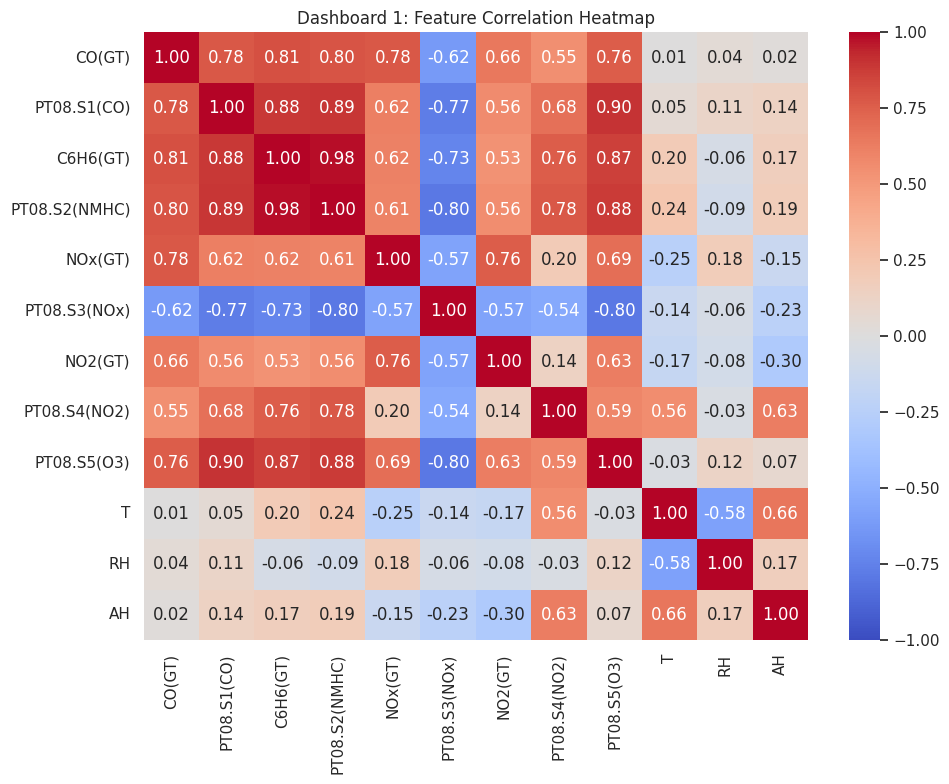

<Figure size 1200x1200 with 0 Axes>

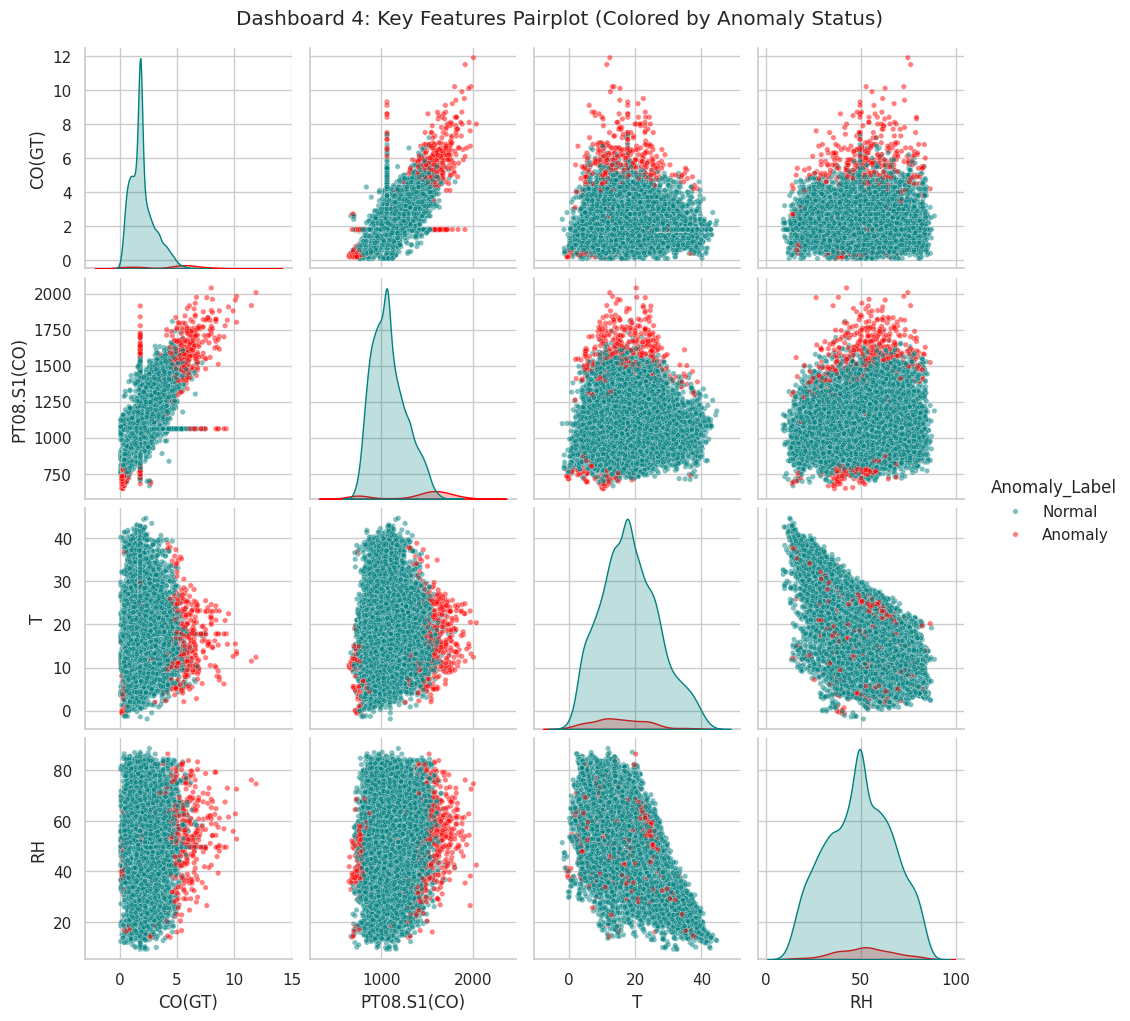

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

# --- 1. Data Preparation ---
df = pd.read_excel('AirQualityUCI.xlsx')
if 'NMHC(GT)' in df.columns:
    df = df.drop(columns=['NMHC(GT)'])
df.replace(-200, np.nan, inplace=True)
num_cols = df.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
data_imputed = imputer.fit_transform(df[num_cols])
data_scaled = StandardScaler().fit_transform(data_imputed)

# Prepare DataFrame for visualization
viz_df = pd.DataFrame(data_imputed, columns=num_cols)

# Calculate PCA (3D)
pca = PCA(n_components=3)
pca_comps = pca.fit_transform(data_scaled)
viz_df['PC1'] = pca_comps[:, 0]
viz_df['PC2'] = pca_comps[:, 1]
viz_df['PC3'] = pca_comps[:, 2]

# Calculate Clusters (K-Means k=3)
km = KMeans(n_clusters=3, random_state=42, n_init=10)
viz_df['Cluster'] = km.fit_predict(data_scaled).astype(str)

# Calculate Anomalies (Isolation Forest)
iso = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
viz_df['Is_Anomaly'] = iso.fit_predict(data_scaled)
viz_df['Anomaly_Label'] = viz_df['Is_Anomaly'].map({1: 'Normal', -1: 'Anomaly'})

print("Rendering Dashboard... (Scroll down to interact with the plots)")

# --- 2. Correlation Heatmap ---
plt.figure(figsize=(10, 8))
sns.heatmap(viz_df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Dashboard 1: Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# --- 3. Interactive PCA & Cluster Visualization (3D) ---
fig1 = px.scatter_3d(
    viz_df, x='PC1', y='PC2', z='PC3',
    color='Cluster',
    opacity=0.6,
    title='Dashboard 2: 3D PCA & Cluster Visualization',
    color_discrete_sequence=px.colors.qualitative.Set1,
    size_max=5
)
fig1.update_traces(marker=dict(size=3))
fig1.show()

# --- 4. Interactive Anomaly Exploration ---
# Hovering over points will show the exact sensor readings for CO, NOx, and Temp
fig2 = px.scatter(
    viz_df, x='PC1', y='PC2',
    color='Anomaly_Label',
    hover_data=['CO(GT)', 'NOx(GT)', 'T', 'RH'],
    opacity=0.7,
    title='Dashboard 3: Interactive Anomaly Explorer (Hover for Details)',
    color_discrete_map={'Normal': 'teal', 'Anomaly': 'red'}
)
fig2.show()

# --- 5. Pairplot (Subset of Key Features to avoid rendering overload) ---
features_to_plot = ['CO(GT)', 'PT08.S1(CO)', 'T', 'RH']
pairplot_df = viz_df[features_to_plot + ['Anomaly_Label']]

plt.figure(figsize=(12, 12))
sns.pairplot(pairplot_df, hue='Anomaly_Label', palette={'Normal': 'teal', 'Anomaly': 'red'}, plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle("Dashboard 4: Key Features Pairplot (Colored by Anomaly Status)", y=1.02)
plt.show()

### 8 Final Visualization Dashboard (Bonus)

To synthesize the analytical findings of this project, this interactive dashboard leverages `plotly` and `seaborn` to provide a multi-faceted exploration of the air quality manifold.

#### 1. Feature Correlation Heatmap
* **Purpose:** Provides a macroscopic summary of linear dependencies across the feature space.
* **Insights:** Instantly highlights the severe multicollinearity among the metal-oxide sensors (e.g., `PT08.S2` and `C6H6` at $r=0.98$) and the negative thermodynamic coupling between Temperature and Relative Humidity.

#### 2. Interactive 3D PCA & Cluster Visualization
* **Purpose:** Extends the previous 2D PCA mapping into the third principal component to fully visualize the dominant variance (capturing ~86.7% of total variance).
* **Interactivity:** You can click and drag to rotate the 3D space.
* **Insights:** Visually demonstrates how the K-Means algorithm partitions the continuous atmospheric gradient into three distinct geometric sectors (baseline, moderate, and high-emission states).

#### 3. Interactive Anomaly Explorer
* **Purpose:** Bridges the gap between abstract PCA coordinates and real-world physical readings.
* **Interactivity:** Hover your cursor over any red anomaly point to dynamically view its raw, pre-scaled physical attributes (e.g., `CO(GT)`, `NOx(GT)`, Temperature, and Humidity).
* **Insights:** Confirms that points isolated by the Isolation Forest on the far right of the PC1 axis correspond to massive physical spikes in Carbon Monoxide and Nitrogen Oxides (rush-hour pollution), while anomalies on the PC2 axis represent unusual thermodynamic combinations.

#### 4. Feature Pairplot (Anomaly Masked)
* **Purpose:** Visualizes the pairwise bivariate distributions of key independent features, colored by the Isolation Forest anomaly mask.
* **Insights:** Demonstrates that anomalies are not randomly distributed but rather cluster in the long tails of the pollutant distributions (e.g., `CO(GT)` vs `PT08.S1`) and along the extreme outer edges of the thermodynamic joint distributions.